# 09 — XAI: Explainability Analysis

Post-hoc analysis of all 5 models (PW, SW, Ensemble, SP, CA). No training required. Ensemble = (PW+SW)/2.

**Sections:**
1. Ground-Truth Letter-Space Analysis
2. Per-Model Error Heatmaps + PW-SW Difference Map
3. Letter Difficulty Ranking (all 5 models + PW vs SW)
4. SHAP Feature Importance on Pairwise DNN
5. Grad-CAM on ResNet18 Backbone
6. Self-Attention Maps from Setwise Transformer
7. Cross-Attention Weight Analysis
8. Per-Font Scatter Plots
9. Per-Style MAE Bar Chart
10. Cumulative Error Distribution
11. Error Distributions per Letter Pair
12. Best & Worst Cases per Style
13. t-SNE of ResNet18 Feature Space

**Output**: images saved to `data/processed/xai/`

In [2]:
# Imports & Setup
import logging
import os
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from dotenv import load_dotenv
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
XAI_DIR = DATA_PROCESSED / "xai"
XAI_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
NUM_CLASSES = 52
FEATURE_DIM = 512
INPUT_DIM = FEATURE_DIM * 2 + NUM_CLASSES * 2
D_MODEL = 32
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
CHAR_TO_IDX = {c: i for i, c in enumerate(LATIN_52)}
IDX_TO_CHAR = {i: c for i, c in enumerate(LATIN_52)}

CATEGORIES_CSV = DATA_PROCESSED / "font_categories.csv"

MONOSPACED_KW = ("mono", "monospace", "code", "console", "courier")

def is_monospaced(family: str, category: str) -> bool:
    fam = family.lower().replace("-", " ").replace("_", " ")
    if "monospace" in (category or "").lower():
        return True
    return any(kw in fam for kw in MONOSPACED_KW)

if not CATEGORIES_CSV.exists():
    log.info("Fetching font categories from Google Fonts API...")
    load_dotenv(PROJECT_ROOT / ".env")
    resp = requests.get(
        "https://www.googleapis.com/webfonts/v1/webfonts",
        params={"key": os.getenv("GOOGLE_FONTS_API_KEY"), "sort": "popularity"},
        timeout=30,
    )
    resp.raise_for_status()
    items = resp.json()["items"]
    rows = [
        {"family": f["family"], "category": f.get("category", "unknown")}
        for f in items
        if not is_monospaced(f["family"], f.get("category", ""))
    ]
    cat_df = pd.DataFrame(rows)
    cat_df.to_csv(CATEGORIES_CSV, index=False)
    log.info("Saved %d families to %s", len(cat_df), CATEGORIES_CSV)
else:
    cat_df = pd.read_csv(CATEGORIES_CSV)
    log.info("Loaded %d font categories from cache", len(cat_df))


family_to_category = dict(zip(cat_df["family"], cat_df["category"]))
def classify_style(family: str) -> str:
    return family_to_category.get(family, "sans-serif").capitalize()


2026-08-20 18:59:42,610 | INFO | Device: cuda
2026-08-20 18:59:42,614 | INFO | Loaded 1868 font categories from cache


In [2]:
# Model Definitions

class PairwiseDNN(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class SetwiseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(FEATURE_DIM * 2, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=2, batch_first=True, dim_feedforward=D_MODEL * 4, activation="relu")
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm = nn.LayerNorm(D_MODEL)
        self.output_proj = nn.Linear(D_MODEL, 1)
    def forward(self, x, mask=None):
        x = self.input_proj(x); x = self.transformer(x, src_key_padding_mask=mask)
        x = self.norm(x); return self.output_proj(x).squeeze(-1)
    def get_hidden(self, x, mask=None):
        x = self.input_proj(x); x = self.transformer(x, src_key_padding_mask=mask)
        return self.norm(x)
    def get_attention_weights(self, x, mask=None):
        x = self.input_proj(x)
        out = self.transformer.layers[0].self_attn(x, x, x, key_padding_mask=mask, need_weights=True, average_attn_weights=False)
        return out[1]

class FusionPairwiseDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM + D_MODEL, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

class PairwiseEncoderCA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64))
    def forward(self, x): return self.net(x)

class CrossAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = PairwiseEncoderCA()
        self.q_proj = nn.Linear(64, 64); self.k_proj = nn.Linear(D_MODEL, 64); self.v_proj = nn.Linear(D_MODEL, 64)
        self.head = nn.Sequential(nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 1))
        self.scale = 64 ** -0.5
    def forward(self, pair, hidden):
        query = self.encoder(pair)
        Q = self.q_proj(query).unsqueeze(1); K = self.k_proj(hidden); V = self.v_proj(hidden)
        attn = torch.softmax(Q @ K.transpose(1, 2) * self.scale, dim=-1)
        context = (attn @ V).squeeze(1)
        fused = torch.cat([query, context], dim=1)
        return self.head(fused).squeeze(-1)

# Load all models
pw_model = PairwiseDNN().to(DEVICE)
pw_model.load_state_dict(torch.load(DATA_PROCESSED / "models" / "pairwise" / "best_model.pt", weights_only=True, map_location=DEVICE))
pw_model.eval(); log.info("PW (NB04) loaded")

sw_model = SetwiseModel().to(DEVICE)
sw_model.load_state_dict(torch.load(DATA_PROCESSED / "models" / "setwise" / "best_model.pt", weights_only=True, map_location=DEVICE))
sw_model.eval(); log.info("SW (NB05) loaded")

sp_model = FusionPairwiseDNN().to(DEVICE)
sp_model.load_state_dict(torch.load(DATA_PROCESSED / "models" / "set_pair_fusion" / "best_model.pt", weights_only=True, map_location=DEVICE))
sp_model.eval(); log.info("SP (NB07) loaded")

ca_model = CrossAttentionModel().to(DEVICE)
ca_model.load_state_dict(torch.load(DATA_PROCESSED / "models" / "cross_attention" / "best_model.pt", weights_only=True, map_location=DEVICE))
ca_model.eval(); log.info("CA (NB08) loaded")

log.info("All 5 models ready (Ensemble computed on-the-fly)")

2026-08-12 22:22:22,180 | INFO | PW (NB04) loaded
2026-08-12 22:22:22,187 | INFO | SW (NB05) loaded
2026-08-12 22:22:22,192 | INFO | SP (NB07) loaded
2026-08-12 22:22:22,199 | INFO | CA (NB08) loaded
2026-08-12 22:22:22,200 | INFO | All 5 models ready (Ensemble computed on-the-fly)


In [3]:
# Load Data & Test Split
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = [s for s in feat_manifest[feat_manifest["status"] == "ok"]["stem"] if s in set(catalog["stem"])]
unique_stems = sorted(ok_stems)
log.info("Fonts with features: %d", len(unique_stems))

stem_family = {}
for _, row in catalog[catalog["stem"].isin(unique_stems)].iterrows():
    stem_family[row["stem"]] = row["family"]

stem_specs = [(s, stem_family.get(s, "unknown"), 0) for s in unique_stems]
all_families = sorted(set(f for _, f, _ in stem_specs))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(all_families)
n_train = int(len(all_families) * 0.8); n_val = int(len(all_families) * 0.1)
test_families = set(all_families[n_train + n_val:])
test_stems = [s for s in unique_stems if stem_family.get(s, "unknown") in test_families]
log.info("Test: %d fonts", len(test_stems))

stem_style = {s: classify_style(stem_family.get(s, "")) for s in test_stems}
style_counts = Counter(stem_style.values())
log.info("Test styles: %s", dict(style_counts))

features_cache = {}; glyph_names_cache = {}; pair_dist_all = {}
for stem in tqdm(test_stems, desc="Loading test data"):
    fz = np.load(FEATURE_DIR / f"{stem}.npz"); features_cache[stem] = fz["features"]
    gz = np.load(GLYPH_DIR / f"{stem}.npz"); glyph_names_cache[stem] = list(gz["glyph_names"])
    left = gz["pair_left"]; right = gz["pair_right"]; dists = gz["pair_distances"]
    lookup = {}
    for i in range(len(left)):
        lookup[(int(left[i]), int(right[i]))] = float(dists[i])
    N = len(gz["glyph_indices"])
    latin_to_local = {int(idx): i for i, idx in enumerate(gz["glyph_indices"])}
    full_mat = np.zeros((N, N), dtype=np.float32)
    for (li, ri), dist in lookup.items():
        if li in latin_to_local and ri in latin_to_local:
            full_mat[latin_to_local[li], latin_to_local[ri]] = dist
    pair_dist_all[stem] = full_mat
log.info("Test data loaded: %.0f MB", sum(a.nbytes for a in features_cache.values()) / 1e6)

sw_pred_cache = {}; sw_hidden_cache = {}
for stem in tqdm(test_stems, desc="Setwise forward"):
    feat = features_cache[stem]; N = len(feat)
    tokens = np.empty((N * N, FEATURE_DIM * 2), dtype=np.float32)
    idx = 0
    for i in range(N):
        fi = feat[i]
        for j in range(N):
            tokens[idx, :FEATURE_DIM] = fi; tokens[idx, FEATURE_DIM:] = feat[j]
            idx += 1
    t = torch.from_numpy(tokens).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = sw_model(t, mask=None).squeeze(0).cpu().numpy()
        hidden = sw_model.get_hidden(t, mask=None).squeeze(0).cpu().numpy()
    sw_pred_cache[stem] = pred.astype(np.float32)
    sw_hidden_cache[stem] = hidden.astype(np.float32)
log.info("Setwise cache built")
sp_ctx_cache = {s: sw_hidden_cache[s].mean(axis=0) for s in test_stems}
log.info("Fusion context cache built")

2026-08-12 22:22:33,962 | INFO | Fonts with features: 7263
2026-08-12 22:22:34,138 | INFO | Test: 786 fonts
2026-08-12 22:22:34,139 | INFO | Test styles: {'Display': 80, 'Sans-serif': 463, 'Serif': 167, 'Handwriting': 76}


Loading test data:   0%|          | 0/786 [00:00<?, ?it/s]

2026-08-12 22:22:48,162 | INFO | Test data loaded: 84 MB


Setwise forward:   0%|          | 0/786 [00:00<?, ?it/s]

2026-08-12 22:22:55,644 | INFO | Setwise cache built
2026-08-12 22:22:55,682 | INFO | Fusion context cache built


In [4]:
# Evaluate All 5 Models (Ensemble = (PW+SW)/2)
results = []
for stem in tqdm(test_stems, desc="Evaluating"):
    names = glyph_names_cache[stem]; feat = features_cache[stem]; N = len(feat)
    full_gt = pair_dist_all[stem]
    sw_pred_stem = sw_pred_cache[stem].reshape(N, N)
    sw_hidden = torch.from_numpy(sw_hidden_cache[stem]).to(DEVICE)
    ctx_t = torch.from_numpy(sp_ctx_cache[stem]).to(DEVICE)
    for li in range(N):
        g1 = names[li]; ci1 = CHAR_TO_IDX.get(g1)
        oh1 = torch.zeros(NUM_CLASSES, device=DEVICE)
        if ci1 is not None: oh1[ci1] = 1.0
        f1 = torch.from_numpy(feat[li]).to(DEVICE)
        for ri in range(N):
            g2 = names[ri]; ci2 = CHAR_TO_IDX.get(g2)
            oh2 = torch.zeros(NUM_CLASSES, device=DEVICE)
            if ci2 is not None: oh2[ci2] = 1.0
            f2 = torch.from_numpy(feat[ri]).to(DEVICE)
            target = full_gt[li, ri]
            x = torch.cat([f1, f2, oh1, oh2]).unsqueeze(0)
            with torch.no_grad(): pred_pw = pw_model(x).item()
            x_fus = torch.cat([x.squeeze(0), ctx_t]).unsqueeze(0)
            with torch.no_grad(): pred_sp = sp_model(x_fus).item()
            pred_sw = float(sw_pred_stem[li, ri])
            sw_h = sw_hidden.unsqueeze(0)
            with torch.no_grad(): pred_ca = ca_model(x, sw_h).item()
            pred_ens = (pred_pw + pred_sw) / 2.0
            results.append({
                "stem": stem, "glyph1": g1, "glyph2": g2, "idx1": ci1, "idx2": ci2,
                "local_i": li, "local_j": ri, "target": target,
                "pred_pw": pred_pw, "pred_sw": pred_sw, "pred_ens": pred_ens,
                "pred_sp": pred_sp, "pred_ca": pred_ca,
                "ae_pw": abs(pred_pw - target), "ae_sw": abs(pred_sw - target),
                "ae_ens": abs(pred_ens - target), "ae_sp": abs(pred_sp - target),
                "ae_ca": abs(pred_ca - target),
            })
results_df = pd.DataFrame(results)
results_df["style"] = results_df["stem"].map(stem_style)
log.info("Evaluation done: %d pairs across %d fonts", len(results_df), len(test_stems))
log.info("  PW: %.4f | SW: %.4f | ENS: %.4f | SP: %.4f | CA: %.4f",
         results_df["ae_pw"].mean(), results_df["ae_sw"].mean(),
         results_df["ae_ens"].mean(), results_df["ae_sp"].mean(),
         results_df["ae_ca"].mean())
for style in ["Sans-serif", "Serif", "Display", "Handwriting"]:
    sub = results_df[results_df["style"] == style]
    log.info("  %s (n=%d): PW=%.2f SW=%.2f ENS=%.2f SP=%.2f CA=%.2f",
             style, len(sub["stem"].unique()),
             sub["ae_pw"].mean(), sub["ae_sw"].mean(), sub["ae_ens"].mean(),
             sub["ae_sp"].mean(), sub["ae_ca"].mean())

Evaluating:   0%|          | 0/786 [00:00<?, ?it/s]

2026-08-12 22:58:33,609 | INFO | Evaluation done: 2125344 pairs across 786 fonts
2026-08-12 22:58:33,629 | INFO |   PW: 3.8949 | SW: 4.6705 | ENS: 3.8804 | SP: 4.0446 | CA: 4.1320
2026-08-12 22:58:33,879 | INFO |   Sans-serif (n=463): PW=3.44 SW=4.17 ENS=3.48 SP=3.79 CA=3.78
2026-08-12 22:58:34,055 | INFO |   Serif (n=167): PW=3.26 SW=4.13 ENS=3.32 SP=3.36 CA=3.45
2026-08-12 22:58:34,158 | INFO |   Display (n=80): PW=6.83 SW=7.13 ENS=6.35 SP=6.43 CA=6.81
2026-08-12 22:58:34,264 | INFO |   Handwriting (n=76): PW=4.93 SW=6.30 ENS=4.95 SP=4.60 CA=4.94


## Section 1: Ground-Truth Letter-Space Analysis

Mean and standard deviation of ground-truth spacing across all test fonts, for all 52×52 letter pairs. This reveals which letter pairs have the most variable spacing across fonts.

C:\Users\angel\AppData\Local\Temp\ipykernel_11340\966485782.py:16: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  gt_mean = np.divide(gt_mean, gt_count, where=gt_count > 0)
C:\Users\angel\AppData\Local\Temp\ipykernel_11340\966485782.py:17: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  gt_var = np.divide(gt_var, gt_count, where=gt_count > 0) - gt_mean * gt_mean


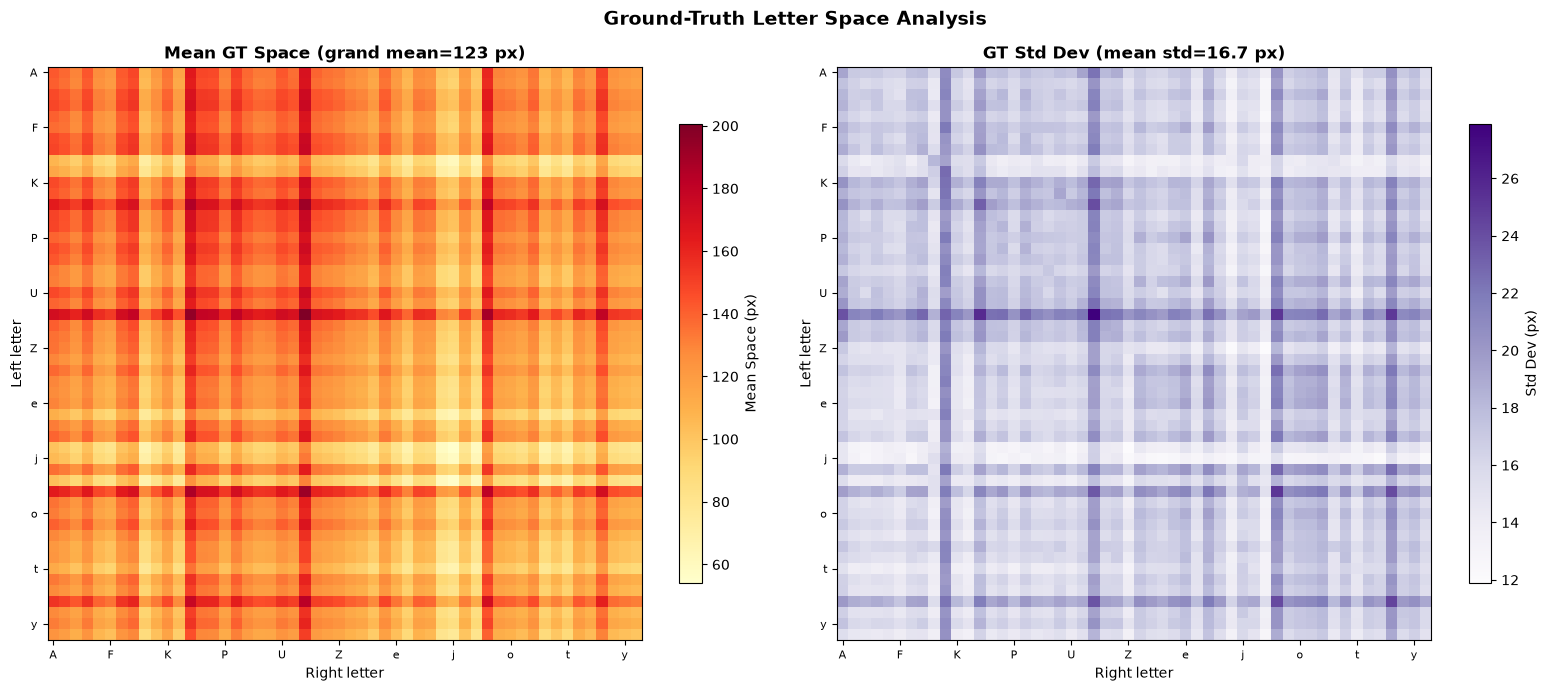

2026-08-13 00:40:55,407 | INFO | Most variable pairs: WW:27.9, WM:25.6, Wm:25.2, mm:25.1, Ww:25.0


In [43]:
# GT Heatmaps
gt_mean = np.zeros((52, 52), dtype=np.float64)
gt_var = np.zeros((52, 52), dtype=np.float64)
gt_count = np.zeros((52, 52), dtype=np.int32)
for stem in test_stems:
    names = glyph_names_cache[stem]; full_mat = pair_dist_all[stem]
    for li in range(len(names)):
        ci1 = CHAR_TO_IDX.get(names[li])
        if ci1 is None: continue
        for ri in range(len(names)):
            ci2 = CHAR_TO_IDX.get(names[ri])
            if ci2 is None: continue
            dist = full_mat[li, ri]
            gt_mean[ci1, ci2] += dist; gt_var[ci1, ci2] += dist * dist
            gt_count[ci1, ci2] += 1
gt_mean = np.divide(gt_mean, gt_count, where=gt_count > 0)
gt_var = np.divide(gt_var, gt_count, where=gt_count > 0) - gt_mean * gt_mean
gt_var = np.maximum(gt_var, 0); gt_std = np.sqrt(gt_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im0 = axes[0].imshow(gt_mean, cmap="YlOrRd", aspect="auto")
axes[0].set_title(f"Mean GT Space (grand mean={gt_mean.mean():.0f} px)", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(0, 52, 5)); axes[0].set_xticklabels([LATIN_52[i] for i in range(0, 52, 5)], fontsize=8)
axes[0].set_yticks(range(0, 52, 5)); axes[0].set_yticklabels([LATIN_52[i] for i in range(0, 52, 5)], fontsize=8)
axes[0].set_xlabel("Right letter"); axes[0].set_ylabel("Left letter")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="Mean Space (px)")
im1 = axes[1].imshow(gt_std, cmap="Purples", aspect="auto")
axes[1].set_title(f"GT Std Dev (mean std={gt_std.mean():.1f} px)", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(0, 52, 5)); axes[1].set_xticklabels([LATIN_52[i] for i in range(0, 52, 5)], fontsize=8)
axes[1].set_yticks(range(0, 52, 5)); axes[1].set_yticklabels([LATIN_52[i] for i in range(0, 52, 5)], fontsize=8)
axes[1].set_xlabel("Right letter"); axes[1].set_ylabel("Left letter")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="Std Dev (px)")
fig.suptitle("Ground-Truth Letter Space Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "01_gt_heatmaps.png", dpi=150, bbox_inches="tight"); plt.show()

gt_std_flat = [(LATIN_52[i], LATIN_52[j], gt_std[i,j]) for i in range(52) for j in range(52) if gt_count[i,j]>0]
gt_std_flat.sort(key=lambda x: x[2], reverse=True)
log.info("Most variable pairs: %s", ", ".join(f"{g1}{g2}:{s:.1f}" for g1,g2,s in gt_std_flat[:5]))

## Section 2: Per-Model Error Heatmaps

52×52 MAE heatmaps for all 5 models. Difference map: PW − SW.

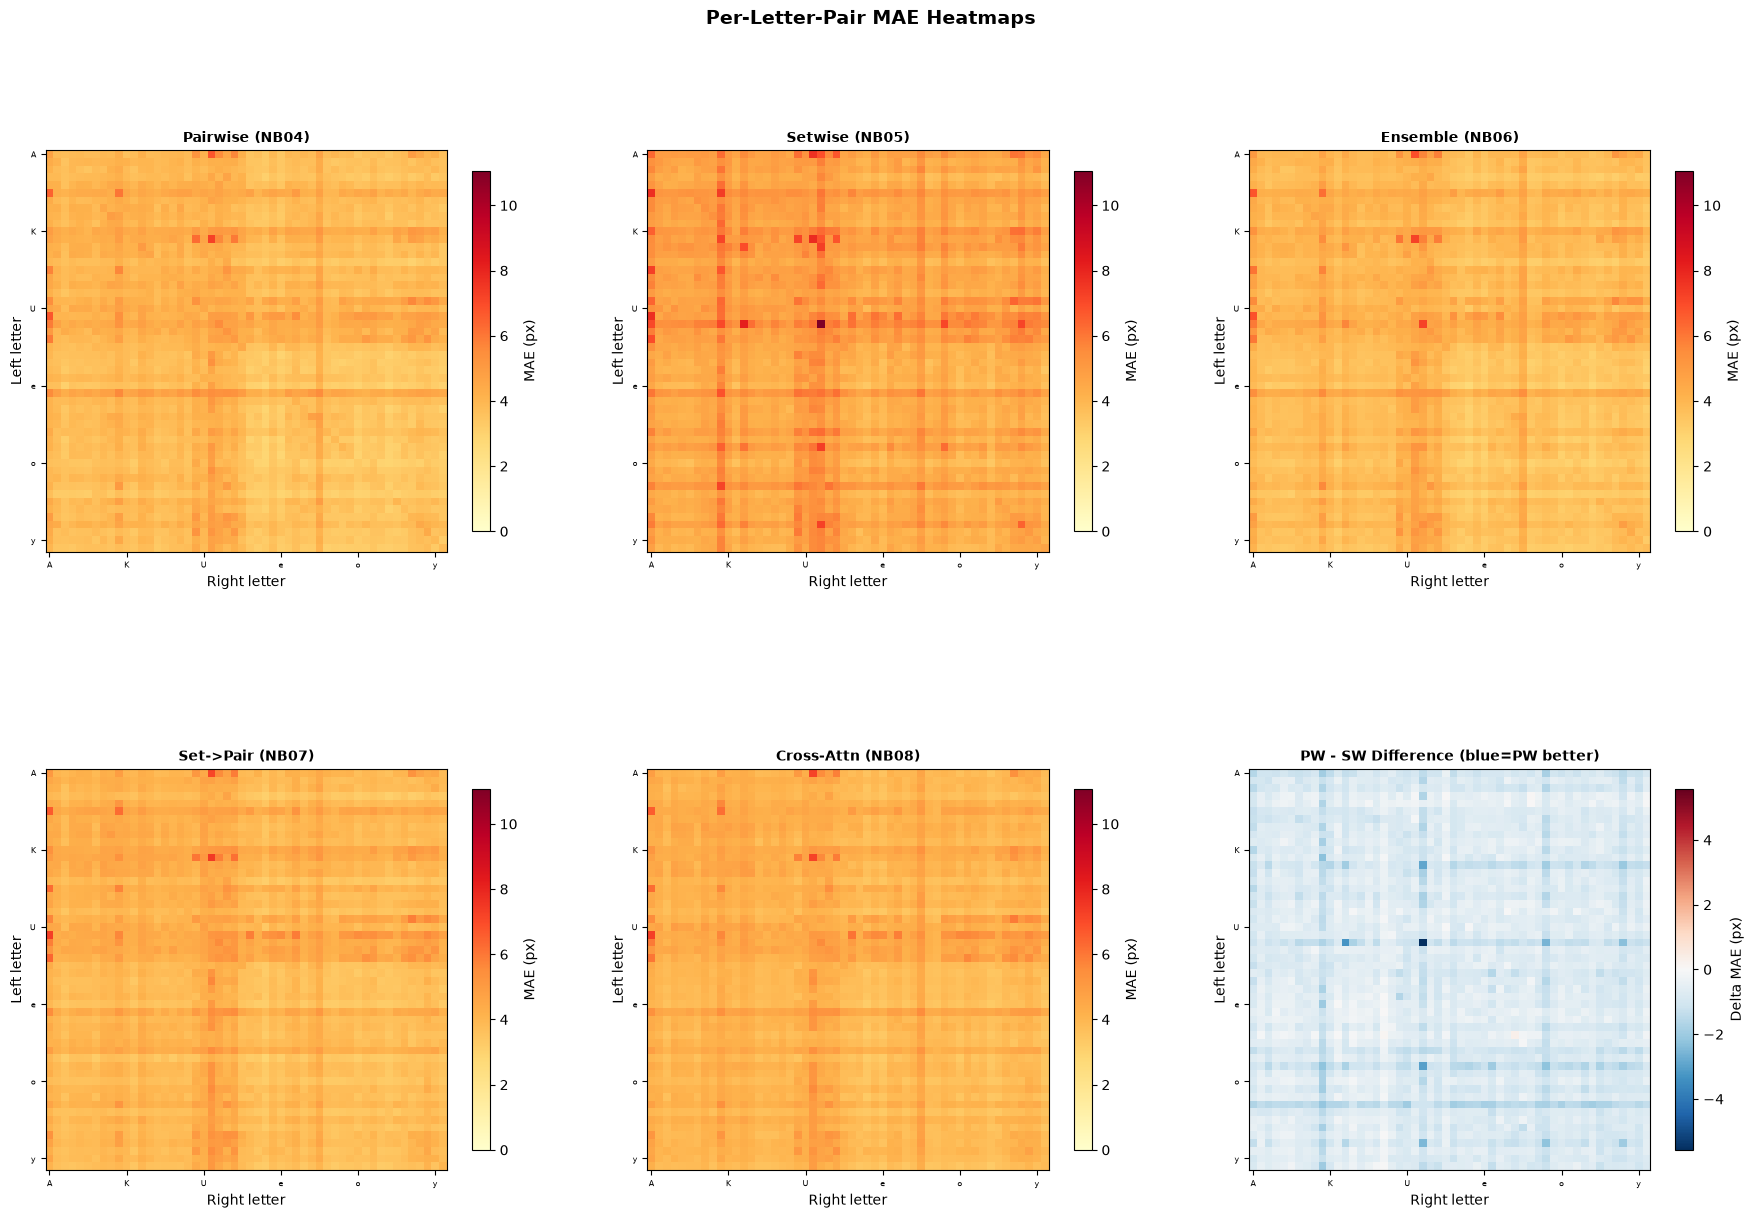

2026-08-13 00:40:57,522 | INFO | PW: best=ec:2.8 es:2.8 | worst=LV:7.2 AV:6.7
2026-08-13 00:40:57,921 | INFO | ENS: best=ec:2.7 es:2.8 | worst=WW:7.2 LV:7.2
2026-08-13 00:40:58,312 | INFO | SW: best=os:3.3 ec:3.4 | worst=WW:11.1 WM:8.1
2026-08-13 00:40:58,718 | INFO | SP: best=lc:2.9 Dc:3.1 | worst=LV:7.5 VA:7.3
2026-08-13 00:40:59,120 | INFO | CA: best=lc:3.2 ec:3.2 | worst=VA:7.3 LV:7.2


In [ ]:
# Error Heatmaps (5 models)
def build_mat(df, col, style_filter=None):
    if style_filter: df = df[df["style"] == style_filter]
    mat = np.full((52, 52), np.nan)
    grouped = df.groupby(["idx1", "idx2"])[col].mean()
    for (i, j), v in grouped.items():
        if i is not None and j is not None: mat[i, j] = v
    return mat

mat_pw = build_mat(results_df, "ae_pw"); mat_sw = build_mat(results_df, "ae_sw")
mat_ens = build_mat(results_df, "ae_ens"); mat_sp = build_mat(results_df, "ae_sp")
mat_ca = build_mat(results_df, "ae_ca"); mat_diff = mat_pw - mat_sw

models_data = [
    ("Pairwise (NB04)", mat_pw), ("Setwise (NB05)", mat_sw),
    ("Ensemble (NB06)", mat_ens), ("Set->Pair (NB07)", mat_sp),
    ("Cross-Attn (NB08)", mat_ca),
]
vmax = max(np.nanmax(m) for _, m in models_data)

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for idx, (title, mat) in enumerate(models_data):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    im = ax.imshow(mat, cmap="YlOrRd", aspect="equal", vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(range(0, 52, 10)); ax.set_xticklabels([LATIN_52[i] for i in range(0, 52, 10)], fontsize=6)
    ax.set_yticks(range(0, 52, 10)); ax.set_yticklabels([LATIN_52[i] for i in range(0, 52, 10)], fontsize=6)
    ax.set_xlabel("Right letter"); ax.set_ylabel("Left letter")
    fig.colorbar(im, ax=ax, shrink=0.7, label="MAE (px)")

ax_diff = axes[1, 2]
vlim = max(abs(np.nanmin(mat_diff)), abs(np.nanmax(mat_diff)))
im_diff = ax_diff.imshow(mat_diff, cmap="RdBu_r", aspect="equal", vmin=-vlim, vmax=vlim)
ax_diff.set_title("PW - SW Difference (blue=PW better)", fontsize=10, fontweight="bold")
ax_diff.set_xticks(range(0, 52, 10)); ax_diff.set_xticklabels([LATIN_52[i] for i in range(0, 52, 10)], fontsize=6)
ax_diff.set_yticks(range(0, 52, 10)); ax_diff.set_yticklabels([LATIN_52[i] for i in range(0, 52, 10)], fontsize=6)
ax_diff.set_xlabel("Right letter"); ax_diff.set_ylabel("Left letter")
fig.colorbar(im_diff, ax=ax_diff, shrink=0.7, label="Delta MAE (px)")
axes[1, 2] = ax_diff

fig.suptitle("Per-Letter-Pair MAE Heatmaps", fontsize=14, fontweight="bold")
plt.subplots_adjust(top=0.92)
plt.savefig(XAI_DIR / "02_error_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

for col, name in [("ae_pw","PW"),("ae_ens","ENS"),("ae_sw","SW"),("ae_sp","SP"),("ae_ca","CA")]:
    pair_stats = results_df.groupby(["glyph1", "glyph2"])[col].mean().sort_values()
    log.info("%s: best=%s %s | worst=%s %s", name,
             f"{pair_stats.index[0][0]}{pair_stats.index[0][1]}:{pair_stats.iloc[0]:.1f}",
             f"{pair_stats.index[1][0]}{pair_stats.index[1][1]}:{pair_stats.iloc[1]:.1f}",
             f"{pair_stats.index[-1][0]}{pair_stats.index[-1][1]}:{pair_stats.iloc[-1]:.1f}",
             f"{pair_stats.index[-2][0]}{pair_stats.index[-2][1]}:{pair_stats.iloc[-2]:.1f}")

## Section 3: Letter Difficulty Ranking

Top: all 5 models ranked by mean error per letter. Bottom: only Pairwise vs Setwise, to highlight the two main architectures.


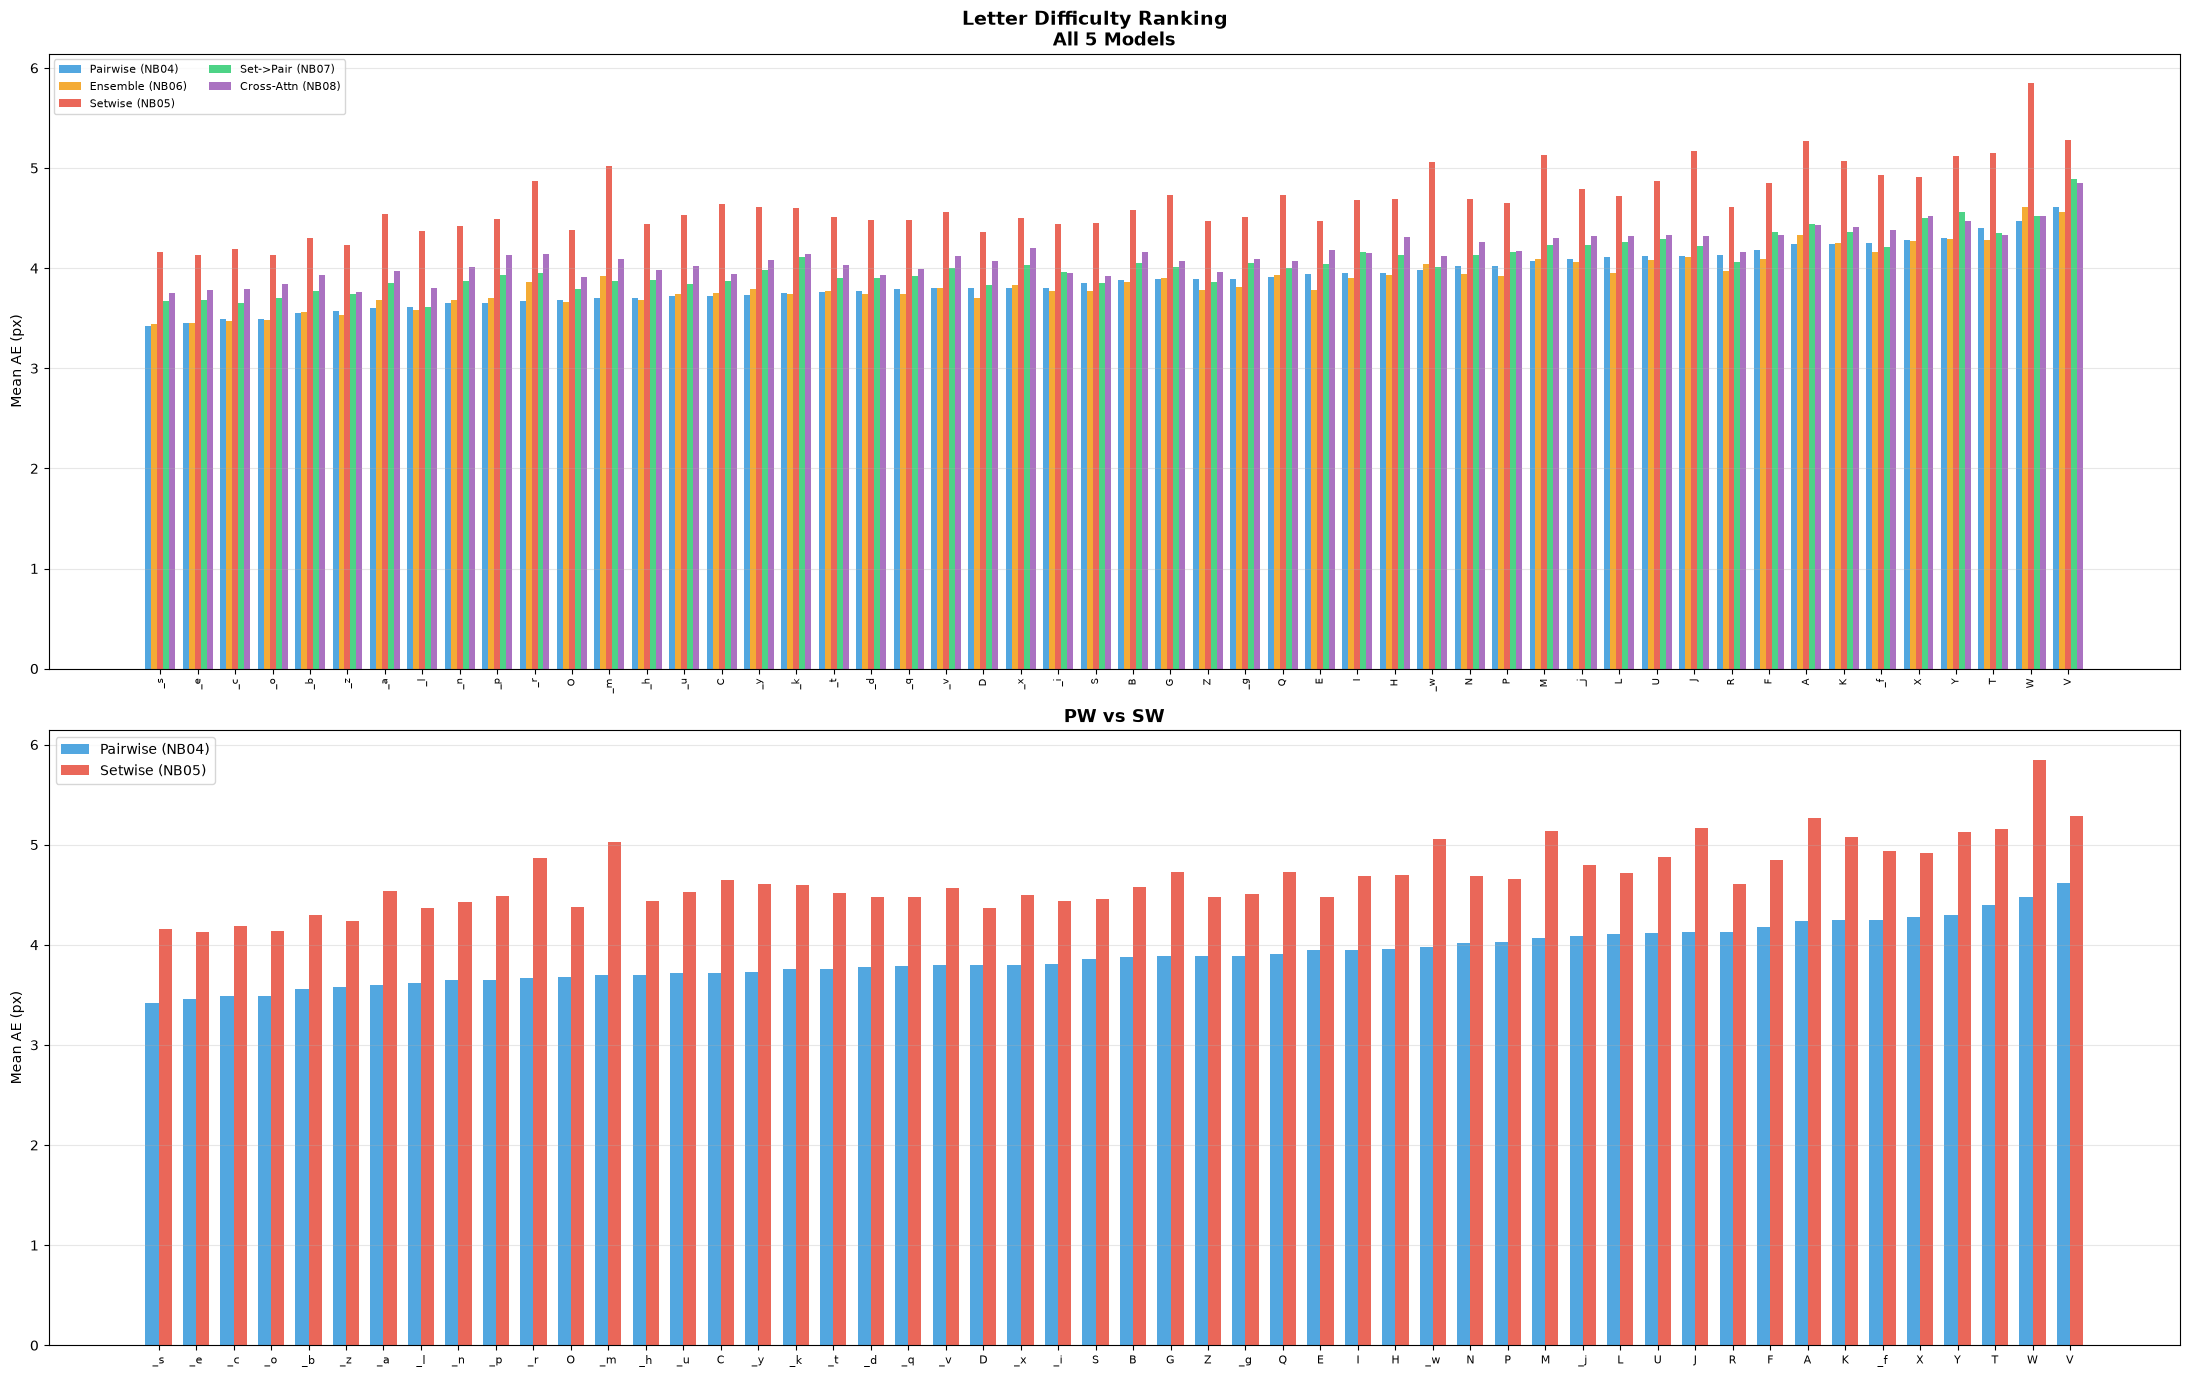

2026-08-13 00:41:00,763 | INFO | Pairwise (NB04) hardest: V(4.6), W(4.5), T(4.4) | easiest: c(3.5), e(3.5), s(3.4)
2026-08-13 00:41:00,764 | INFO | Ensemble (NB06) hardest: W(4.6), V(4.6), A(4.3) | easiest: c(3.5), e(3.4), s(3.4)
2026-08-13 00:41:00,764 | INFO | Setwise (NB05) hardest: W(5.8), V(5.3), A(5.3) | easiest: s(4.2), o(4.1), e(4.1)
2026-08-13 00:41:00,765 | INFO | Set->Pair (NB07) hardest: V(4.9), Y(4.6), W(4.5) | easiest: s(3.7), c(3.7), l(3.6)
2026-08-13 00:41:00,765 | INFO | Cross-Attn (NB08) hardest: V(4.8), X(4.5), W(4.5) | easiest: e(3.8), z(3.8), s(3.8)


In [45]:
# Letter Difficulty — all 5 models + PW vs SW (single cell)
def letter_diff(df, col):
    lm = df.groupby("idx1")[col].mean()
    rm = df.groupby("idx2")[col].mean()
    result = {}
    for idx in range(52):
        means = []
        if idx in lm.index: means.append(lm[idx])
        if idx in rm.index: means.append(rm[idx])
        if means: result[idx] = np.mean(means)
    return result

letter_pw = letter_diff(results_df, "ae_pw"); letter_ens = letter_diff(results_df, "ae_ens")
letter_sw = letter_diff(results_df, "ae_sw"); letter_sp = letter_diff(results_df, "ae_sp")
letter_ca = letter_diff(results_df, "ae_ca")
sorted_chars = sorted(letter_pw.keys(), key=lambda x: letter_pw[x])
assert len(sorted_chars) == 52, f"Expected 52 chars, got {len(sorted_chars)}"

def char_labels():
    return [f"_{LATIN_52[c]}" if LATIN_52[c].islower() else LATIN_52[c] for c in sorted_chars]

models_rank = [
    (letter_pw, "Pairwise (NB04)", "#3498db"),
    (letter_ens, "Ensemble (NB06)", "#f39c12"),
    (letter_sw, "Setwise (NB05)", "#e74c3c"),
    (letter_sp, "Set->Pair (NB07)", "#2ecc71"),
    (letter_ca, "Cross-Attn (NB08)", "#9b59b6"),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 14))
x = np.arange(52)

# Left: all 5 models
w = 0.16
for offset, (ld, label, color) in enumerate(models_rank):
    pos = x + (offset - 2) * w
    means = [ld[c] for c in sorted_chars]
    ax1.bar(pos, means, w, label=label, color=color, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(char_labels(), fontsize=7, rotation=90)
ax1.set_ylabel("Mean AE (px)")
ax1.set_title("All 5 Models", fontsize=13, fontweight="bold")
ax1.legend(fontsize=8, ncol=2); ax1.grid(axis="y", alpha=0.3)

# Right: PW vs SW
w2 = 0.35
pw_means = [letter_pw[c] for c in sorted_chars]
sw_means = [letter_sw[c] for c in sorted_chars]
ax2.bar(x - w2/2, pw_means, w2, label="Pairwise (NB04)", color="#3498db", alpha=0.85)
ax2.bar(x + w2/2, sw_means, w2, label="Setwise (NB05)", color="#e74c3c", alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(char_labels(), fontsize=8)
ax2.set_ylabel("Mean AE (px)")
ax2.set_title("PW vs SW", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10); ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Letter Difficulty Ranking", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "03_letter_ranking.png", dpi=150, bbox_inches="tight"); plt.show()

for ld, label, _ in models_rank:
    sorted_ld = sorted(ld.items(), key=lambda x: x[1], reverse=True)
    log.info("%s hardest: %s | easiest: %s", label,
             ", ".join(f"{LATIN_52[i]}({v:.1f})" for i,v in sorted_ld[:3]),
             ", ".join(f"{LATIN_52[i]}({v:.1f})" for i,v in sorted_ld[-3:]))

## Section 4: SHAP Feature Importance

Measures how much each input feature group contributes to the pairwise model's predictions. The input is 1128-d: 512 visual features (letter A) + 512 visual features (letter B) + 52 one-hot (identity A) + 52 one-hot (identity B). SHAP decomposes each prediction into per-feature contributions.

2026-08-13 00:42:33,902 | INFO | SHAP: 100 background + 200 explained
2026-08-13 00:42:34,677 | INFO | SHAP computed: (200, 1128)
2026-08-13 00:42:34,679 | INFO | SHAP: Visual=96.0% | Identity=4.0%


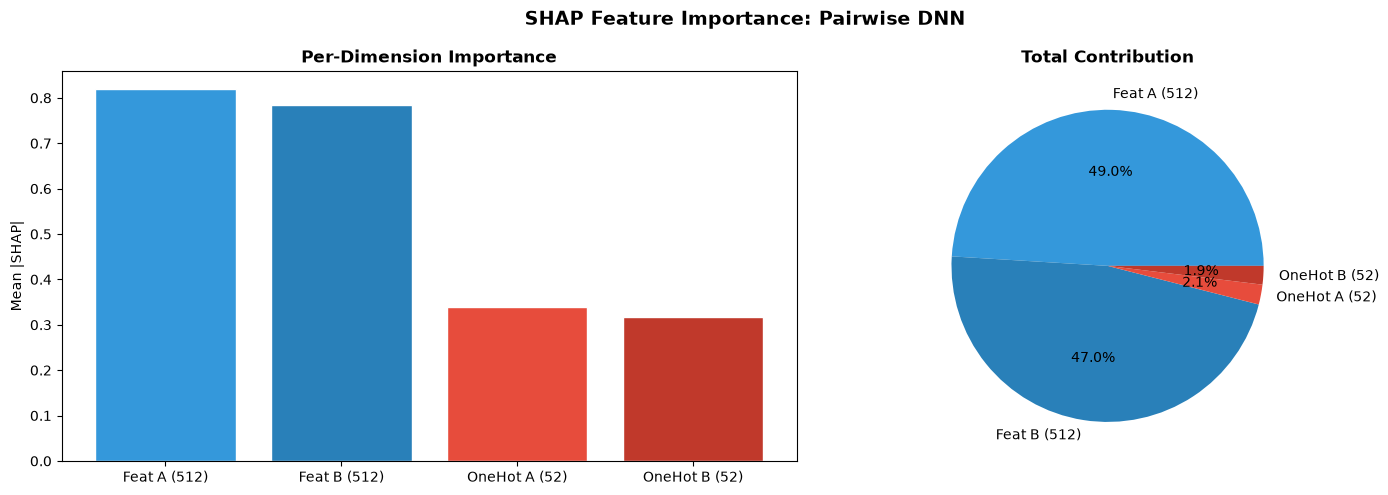

In [60]:
# SHAP on Pairwise DNN
import shap
bg_indices = rng.choice(len(results_df), min(100, len(results_df)), replace=False)
bg_tensors = []
for idx in bg_indices:
    row = results_df.iloc[idx]; stem = row["stem"]
    li, lj = row["local_i"], row["local_j"]; ci1, ci2 = row["idx1"], row["idx2"]
    feat = features_cache[stem]; f1 = torch.from_numpy(feat[li]); f2 = torch.from_numpy(feat[lj])
    oh1 = torch.zeros(NUM_CLASSES); oh2 = torch.zeros(NUM_CLASSES)
    if ci1 is not None: oh1[ci1] = 1.0
    if ci2 is not None: oh2[ci2] = 1.0
    bg_tensors.append(torch.cat([f1, f2, oh1, oh2]).numpy())
background = np.stack(bg_tensors)
explain_indices = rng.choice(len(results_df), min(200, len(results_df)), replace=False)
explain_tensors = []
for idx in explain_indices:
    row = results_df.iloc[idx]; stem = row["stem"]
    li, lj = row["local_i"], row["local_j"]; ci1, ci2 = row["idx1"], row["idx2"]
    feat = features_cache[stem]; f1 = torch.from_numpy(feat[li]); f2 = torch.from_numpy(feat[lj])
    oh1 = torch.zeros(NUM_CLASSES); oh2 = torch.zeros(NUM_CLASSES)
    if ci1 is not None: oh1[ci1] = 1.0
    if ci2 is not None: oh2[ci2] = 1.0
    explain_tensors.append(torch.cat([f1, f2, oh1, oh2]).numpy())
explain_data = np.stack(explain_tensors)
log.info("SHAP: %d background + %d explained", len(background), len(explain_data))

class PWrap(nn.Module):
    def __init__(self): super().__init__(); self.model = PairwiseDNN()
    def forward(self, x): return self.model(x).unsqueeze(-1)
pw_cpu = PWrap()
pw_cpu.model.load_state_dict(torch.load(DATA_PROCESSED / "models" / "pairwise" / "best_model.pt", weights_only=True, map_location="cpu"))
pw_cpu.eval()
explainer = shap.DeepExplainer(pw_cpu, torch.from_numpy(background[:100]).float())
shap_values = explainer.shap_values(torch.from_numpy(explain_data[:200]).float())
if isinstance(shap_values, list): shap_values = shap_values[0]
shap_values = shap_values.squeeze(-1)
log.info("SHAP computed: %s", shap_values.shape)

fi = np.abs(shap_values).mean(axis=0)
fi_featA, fi_featB = fi[:512], fi[512:1024]
fi_ohA, fi_ohB = fi[1024:1076], fi[1076:1128]
total = fi_featA.sum()+fi_featB.sum()+fi_ohA.sum()+fi_ohB.sum()
pct_featA = 100*fi_featA.sum()/total; pct_featB = 100*fi_featB.sum()/total
pct_ohA = 100*fi_ohA.sum()/total; pct_ohB = 100*fi_ohB.sum()/total
log.info("SHAP: Visual=%.1f%% | Identity=%.1f%%", pct_featA+pct_featB, pct_ohA+pct_ohB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
cats = ["Feat A (512)", "Feat B (512)", "OneHot A (52)", "OneHot B (52)"]
means = [fi_featA.mean(), fi_featB.mean(), fi_ohA.mean(), fi_ohB.mean()]
colors_shap = ["#3498db", "#2980b9", "#e74c3c", "#c0392b"]
ax1.bar(cats, means, color=colors_shap, edgecolor="white")
ax1.set_ylabel("Mean |SHAP|"); ax1.set_title("Per-Dimension Importance", fontweight="bold")
ax2.pie([pct_featA, pct_featB, pct_ohA, pct_ohB], labels=cats, autopct="%1.1f%%", colors=colors_shap)
ax2.set_title("Total Contribution", fontweight="bold")
fig.suptitle("SHAP Feature Importance: Pairwise DNN", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "04_shap_importance.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 5: Grad-CAM on ResNet18

Red areas show which pixels the ResNet18 considers most discriminative for classifying each letter. The model focuses on structurally diagnostic regions: O=contour, H=crossbar+stems, I=stem, W=apex junctions, A=apex+crossbar, E=serifs+horizontal bars.

2026-08-13 00:41:02,227 | INFO | Grad-CAM font: Aboreto_regular (Display)


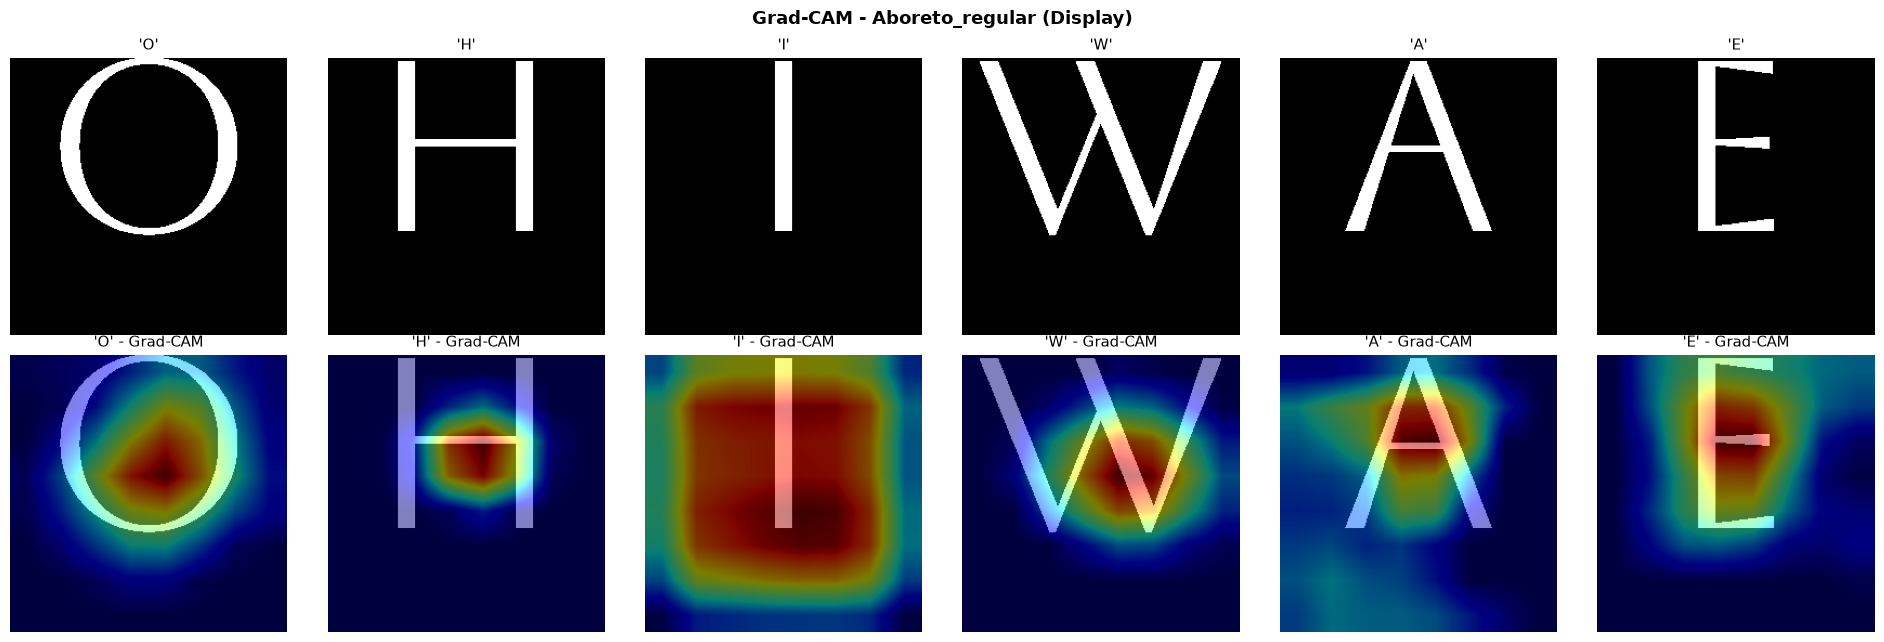

In [47]:
# Grad-CAM
from torchvision.models import resnet18
backbone = resnet18(num_classes=NUM_CLASSES)
backbone.load_state_dict(torch.load(DATA_PROCESSED / "models" / "resnet_classifier.pt", weights_only=True, map_location=DEVICE))
backbone.to(DEVICE); backbone.eval()
target_letters = ["O","H","I","W","A","E"]
gc_stem = test_stems[0]
for s in test_stems:
    if all(c in glyph_names_cache[s] for c in target_letters):
        gc_stem = s; break
log.info("Grad-CAM font: %s (%s)", gc_stem, stem_style.get(gc_stem,"?"))
activations = {}; gradients = {}
def fw_h(m,i,o): activations["v"] = o
def bw_h(m,gi,go): gradients["v"] = go[0]
backbone.layer4[1].conv2.register_forward_hook(fw_h)
backbone.layer4[1].conv2.register_full_backward_hook(bw_h)

gz = np.load(GLYPH_DIR / f"{gc_stem}.npz"); imgs = gz["glyph_images"]
names_f = list(gz["glyph_names"])
fig, axes = plt.subplots(2, len(target_letters), figsize=(3.2*len(target_letters), 6.5))
for j, lt in enumerate(target_letters):
    idx = names_f.index(lt); img = imgs[idx].astype(np.float32)
    t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).repeat(1,3,1,1).to(DEVICE); t.requires_grad=True
    backbone.zero_grad(); out = backbone(t); out[0,CHAR_TO_IDX[lt]].backward()
    act = activations["v"].detach(); grad = gradients["v"].detach()
    w = grad.mean(dim=(2,3),keepdim=True); cam = (w*act).sum(dim=1).squeeze(0)
    cam = F.relu(cam); cam = (cam-cam.min())/(cam.max()+1e-8)
    cam = F.interpolate(cam.unsqueeze(0).unsqueeze(0),size=(256,256),mode="bilinear").squeeze().cpu().numpy()
    axes[0,j].imshow(img,cmap="gray"); axes[0,j].set_title(f"'{lt}'",fontsize=11); axes[0,j].axis("off")
    axes[1,j].imshow(img,cmap="gray"); axes[1,j].imshow(cam,cmap="jet",alpha=0.5)
    axes[1,j].set_title(f"'{lt}' - Grad-CAM",fontsize=11); axes[1,j].axis("off")
fig.suptitle(f"Grad-CAM - {gc_stem} ({stem_style.get(gc_stem,'?')})",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "05_gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 6: Self-Attention Maps

The self-attention matrix of the Setwise Transformer (Head 1). Near-uniform attention for all fonts (entropy >85% of max) confirms insufficient capacity for 2,704 tokens.

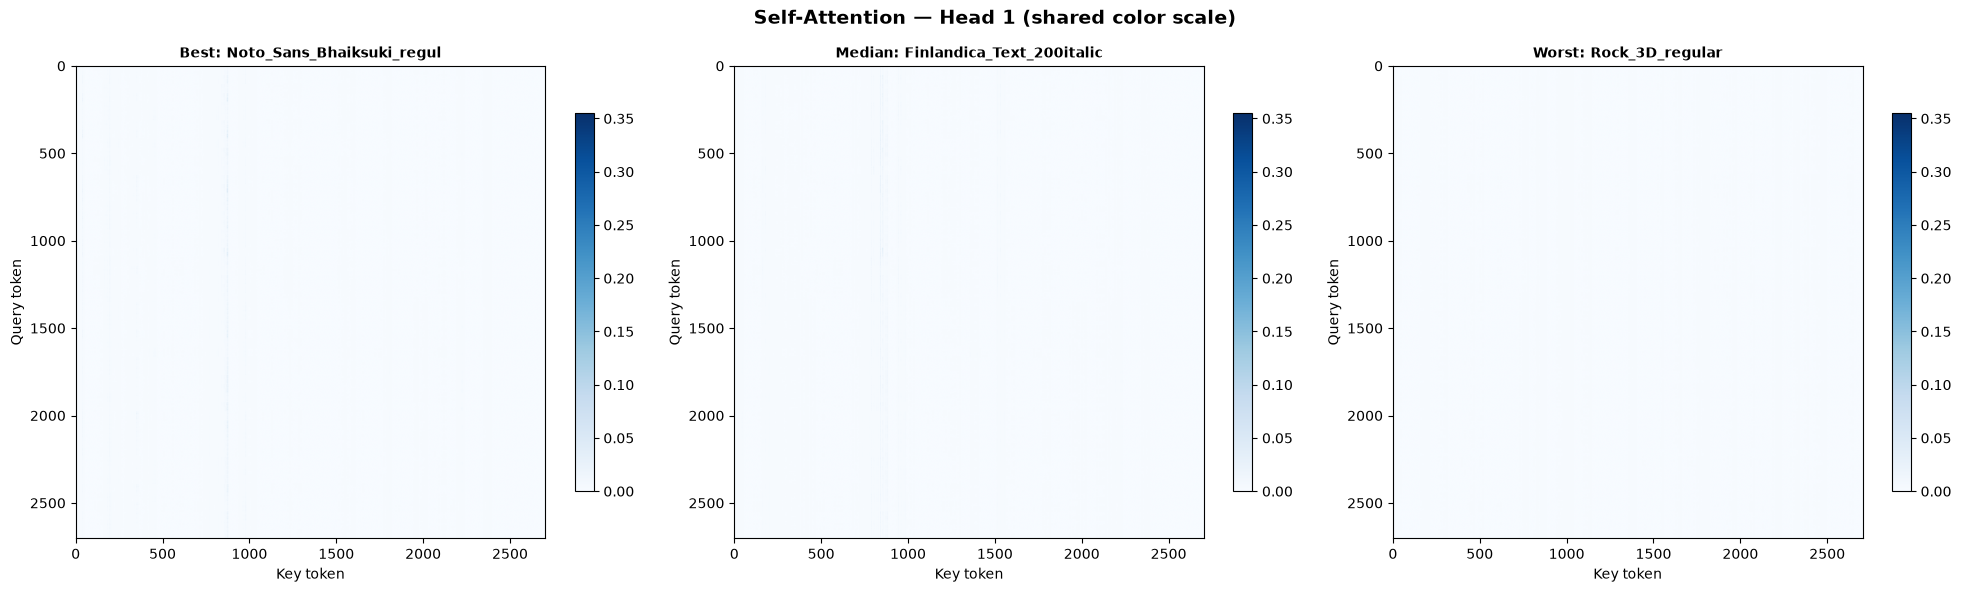

2026-08-13 00:41:10,177 | INFO | Best (Noto_Sans_Bhaiksuki_regul) H1: ent=7.44/7.90 (94.2% uniform)
2026-08-13 00:41:10,178 | INFO | Median (Finlandica_Text_200italic) H1: ent=7.44/7.90 (94.2% uniform)
2026-08-13 00:41:10,178 | INFO | Worst (Rock_3D_regular) H1: ent=7.44/7.90 (94.2% uniform)


In [48]:
# Self-Attention — Head 1 only, shared color scale
font_mae_pw_series = results_df.groupby("stem")["ae_pw"].mean().sort_values()
best_st = font_mae_pw_series.index[0]; med_st = font_mae_pw_series.index[len(font_mae_pw_series)//2]; worst_st = font_mae_pw_series.index[-1]
attn_stems = [(best_st,"Best"),(med_st,"Median"),(worst_st,"Worst")]

attn_maps = []; global_max = 0.0
for stem, _ in attn_stems:
    N_st = len(features_cache[stem]); feat = features_cache[stem]
    tokens = np.empty((N_st*N_st, FEATURE_DIM*2), dtype=np.float32); idx = 0
    for i in range(N_st):
        for j in range(N_st): tokens[idx,:FEATURE_DIM]=feat[i]; tokens[idx,FEATURE_DIM:]=feat[j]; idx+=1
    t = torch.from_numpy(tokens).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): attn = sw_model.get_attention_weights(t).squeeze(0).cpu().numpy()
    attn_maps.append(attn[0]); global_max = max(global_max, attn[0].max())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for row_idx, (stem, label) in enumerate(attn_stems):
    ax = axes[row_idx]
    im = ax.imshow(attn_maps[row_idx], cmap="Blues", aspect="auto", vmin=0, vmax=global_max)
    ax.set_title(f"{label}: {stem[:25]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Key token"); ax.set_ylabel("Query token")
    fig.colorbar(im, ax=ax, shrink=0.8)
    avg_row = attn_maps[row_idx].mean(axis=0)
    ent = -np.sum(avg_row * np.log(avg_row + 1e-10))
    N_tok = len(features_cache[stem]); max_ent = np.log(N_tok * N_tok)
fig.suptitle("Self-Attention — Head 1 (shared color scale)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "06_self_attention.png", dpi=150, bbox_inches="tight"); plt.show()
for row_idx, (stem, label) in enumerate(attn_stems):
    log.info("%s (%s) H1: ent=%.2f/%.2f (%.1f%% uniform)", label, stem[:25], ent, max_ent, 100*ent/max_ent)

## Section 7: Cross-Attention Weights

The cross-attention model uses pairwise encoder output as query over frozen setwise hidden states. Distributions indistinguishable from uniform (KL≈0) confirm the SW hidden states carry no queryable information.

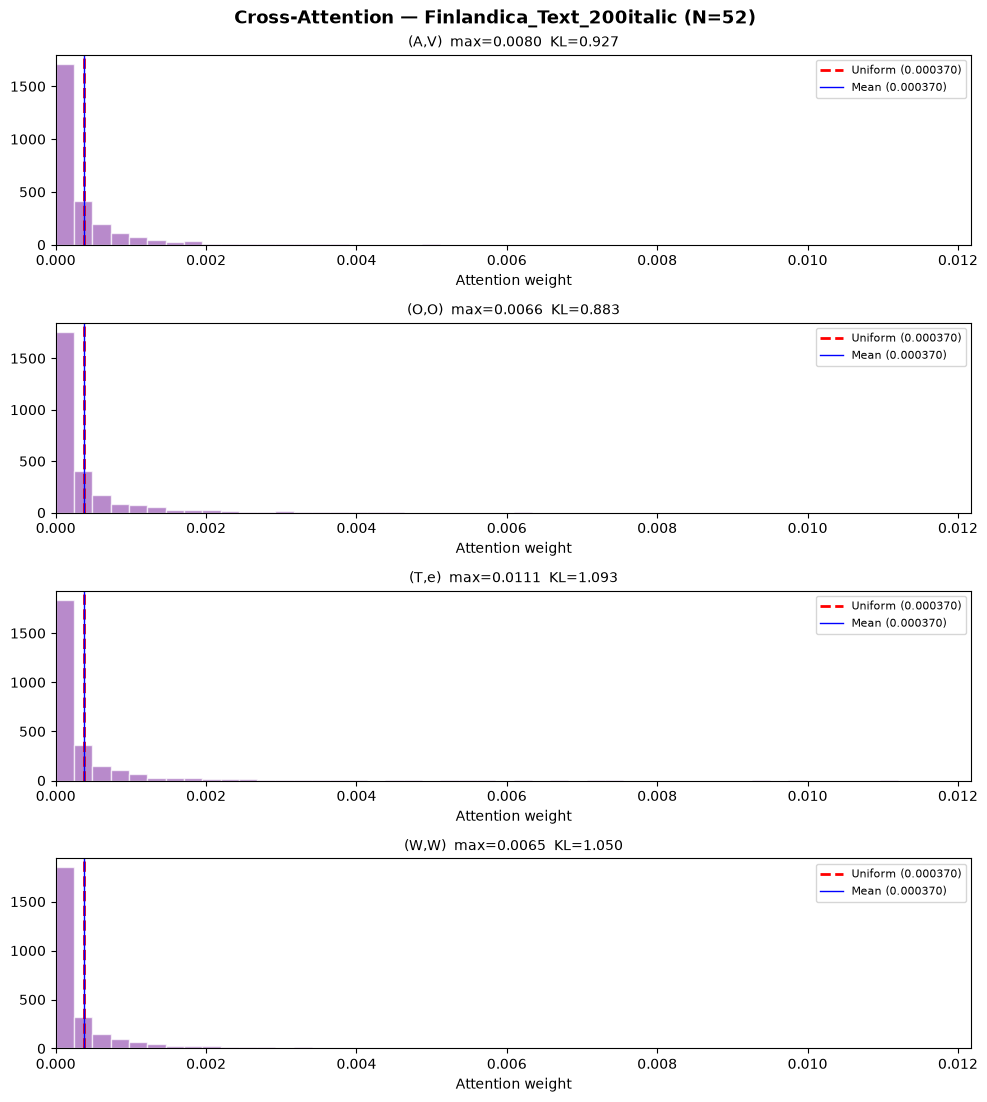

In [49]:
# Cross-Attention — 4 pairs, unified x-axis
ca_stem = med_st; N_ca = len(glyph_names_cache[ca_stem])
names_ca = glyph_names_cache[ca_stem]; feat_ca = features_cache[ca_stem]
sw_h_ca = torch.from_numpy(sw_hidden_cache[ca_stem]).to(DEVICE)
pairs = [("A","V"), ("O","O"), ("T","e"), ("W","W")]
pairs = [(g1,g2) for g1,g2 in pairs if g1 in names_ca and g2 in names_ca]
uv = 1.0 / (N_ca * N_ca)

all_aw = []
for g1, g2 in pairs:
    i1 = names_ca.index(g1); i2 = names_ca.index(g2)
    ci1, ci2 = CHAR_TO_IDX[g1], CHAR_TO_IDX[g2]
    f1 = torch.from_numpy(feat_ca[i1]).to(DEVICE); f2 = torch.from_numpy(feat_ca[i2]).to(DEVICE)
    oh1 = torch.zeros(NUM_CLASSES, device=DEVICE); oh1[ci1] = 1.0
    oh2 = torch.zeros(NUM_CLASSES, device=DEVICE); oh2[ci2] = 1.0
    x_pair = torch.cat([f1,f2,oh1,oh2]).unsqueeze(0)
    with torch.no_grad():
        Q = ca_model.q_proj(ca_model.encoder(x_pair)).unsqueeze(1)
        K = ca_model.k_proj(sw_h_ca.unsqueeze(0))
        aw = F.softmax(Q @ K.transpose(1,2) * ca_model.scale, dim=-1).squeeze().cpu().numpy()
        all_aw.append(aw)
global_xmax = max(a.max() for a in all_aw) * 1.1

fig, axes = plt.subplots(len(pairs), 1, figsize=(10, 2.8*len(pairs)))
if len(pairs) == 1: axes = [axes]
for pi, (g1, g2) in enumerate(pairs):
    aw = all_aw[pi]
    axes[pi].hist(aw, bins=50, color="#9b59b6", alpha=0.7, edgecolor="white", range=(0, global_xmax))
    axes[pi].axvline(uv, color="red", linestyle="--", linewidth=2, label=f"Uniform ({uv:.6f})")
    axes[pi].axvline(aw.mean(), color="blue", linewidth=1, label=f"Mean ({aw.mean():.6f})")
    kl = np.sum(aw * np.log(aw / (uv + 1e-10) + 1e-10))
    axes[pi].set_title(f"({g1},{g2})  max={aw.max():.4f}  KL={kl:.3f}", fontsize=10)
    axes[pi].legend(fontsize=8); axes[pi].set_xlim(0, global_xmax); axes[pi].set_xlabel("Attention weight")
fig.suptitle(f"Cross-Attention — {ca_stem} (N={N_ca})", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "07_cross_attention.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 8: Per-Font Scatter Plots

Each point = one test font, colored by style. Diagonal = y=x. Points below the line: the comparison model beats Pairwise on that font.

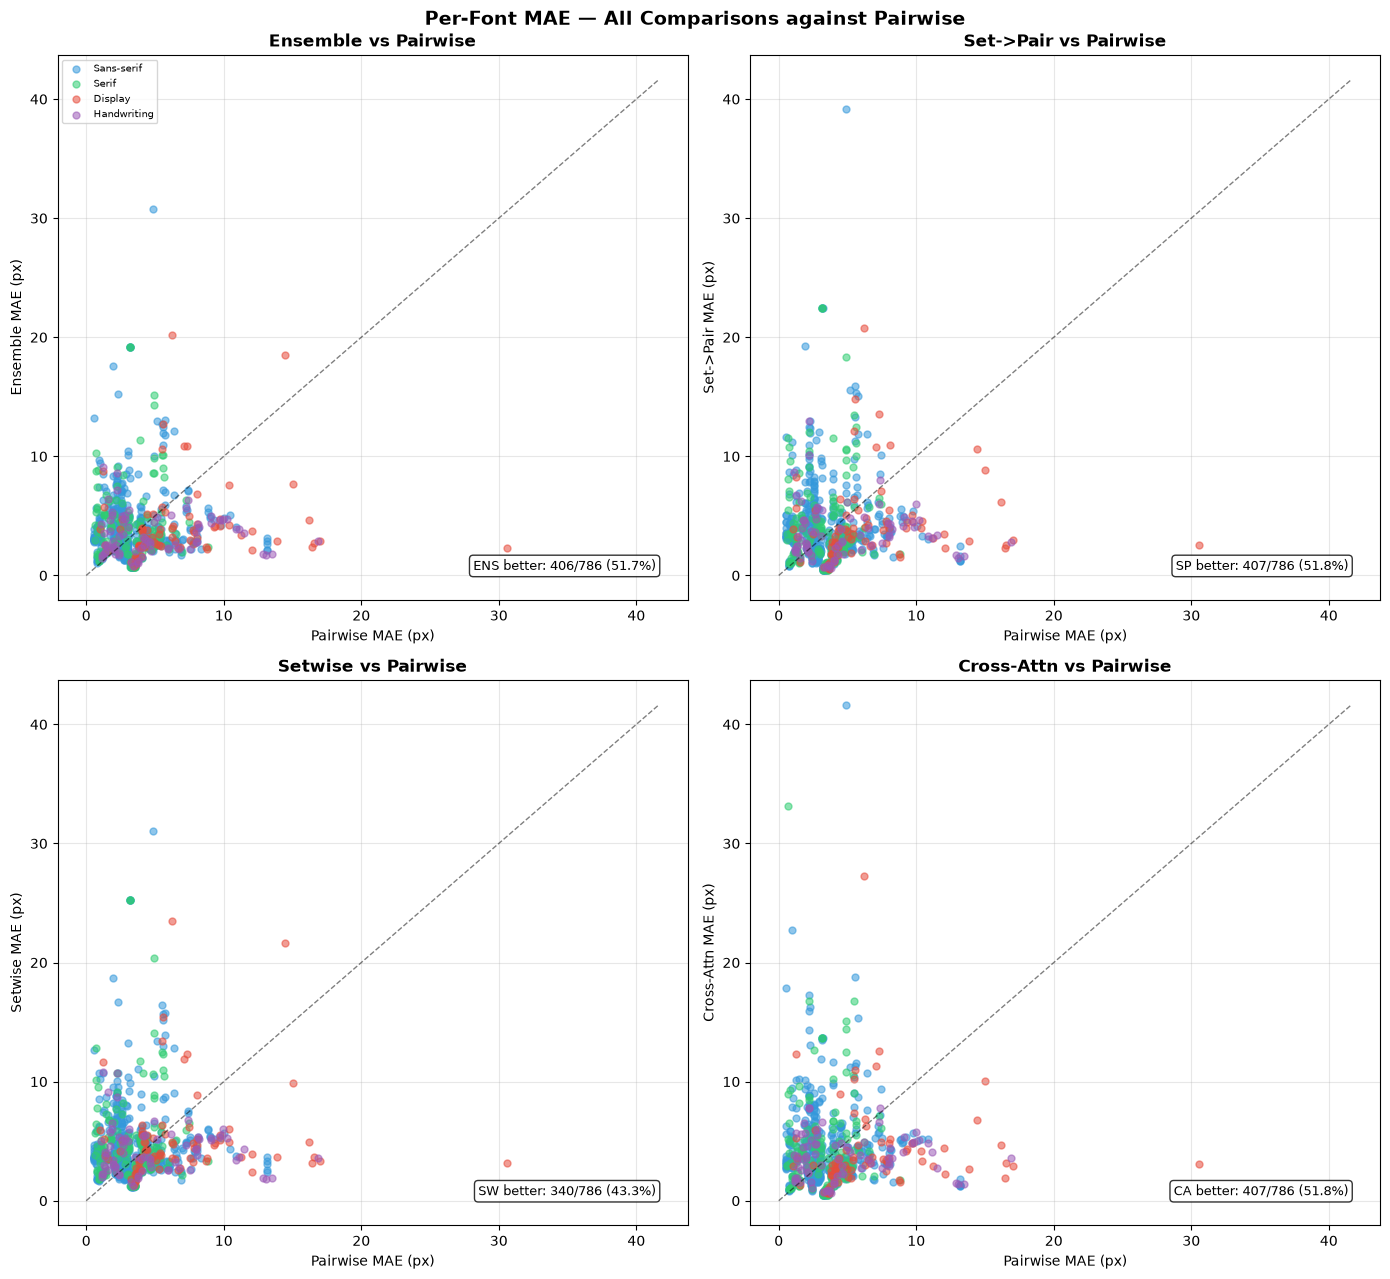

2026-08-13 00:41:12,588 | INFO | ENS better: 406/786 (51.7%)
2026-08-13 00:41:12,589 | INFO | SP better: 407/786 (51.8%)
2026-08-13 00:41:12,590 | INFO | SW better: 340/786 (43.3%)
2026-08-13 00:41:12,590 | INFO | CA better: 407/786 (51.8%)


In [50]:
# Per-Font Scatter — 2×2 grid, colored by style
font_mae_ens = results_df.groupby("stem")["ae_ens"].mean()
font_mae_sp = results_df.groupby("stem")["ae_sp"].mean()
font_mae_sw = results_df.groupby("stem")["ae_sw"].mean()
font_mae_ca = results_df.groupby("stem")["ae_ca"].mean()

font_df = pd.DataFrame({
    "stem": list(font_mae_pw_series.index), "mae_pw": font_mae_pw_series.values,
    "mae_ens": font_mae_ens.values, "mae_sp": font_mae_sp.values,
    "mae_sw": font_mae_sw.values, "mae_ca": font_mae_ca.values,
})
font_df["style"] = font_df["stem"].map(stem_style)

style_colors = {"Sans-serif": "#3498db", "Serif": "#2ecc71", "Display": "#e74c3c", "Handwriting": "#9b59b6"}

comparisons = [
    ("mae_ens", "Ensemble vs Pairwise", "ENS better"),
    ("mae_sp", "Set->Pair vs Pairwise", "SP better"),
    ("mae_sw", "Setwise vs Pairwise", "SW better"),
    ("mae_ca", "Cross-Attn vs Pairwise", "CA better"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 13))
mx = max(font_df["mae_pw"].max(), font_df["mae_ens"].max(), font_df["mae_sp"].max(), font_df["mae_sw"].max(), font_df["mae_ca"].max())
for idx, (col, title, better_label) in enumerate(comparisons):
    ax = axes[idx//2, idx%2]
    for sty, c in style_colors.items():
        sub = font_df[font_df["style"] == sty]
        ax.scatter(sub["mae_pw"], sub[col], alpha=0.55, c=c, s=25, label=sty)
    ax.plot([0, mx], [0, mx], "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Pairwise MAE (px)"); ax.set_ylabel(f"{title.split(' vs')[0]} MAE (px)")
    ax.set_title(title, fontweight="bold"); ax.grid(True, alpha=0.3)
    n_better = (font_df[col] < font_df["mae_pw"]).sum()
    ax.text(0.95, 0.05, f"{better_label}: {n_better}/{len(font_df)} ({100*n_better/len(font_df):.1f}%)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Per-Font MAE — All Comparisons against Pairwise", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "08_per_font_scatter.png", dpi=150, bbox_inches="tight"); plt.show()
for col, _, label in comparisons:
    n = (font_df[col] < font_df["mae_pw"]).sum()
    log.info("%s: %d/%d (%.1f%%)", label, n, len(font_df), 100*n/len(font_df))

## Section 9: Per-Style MAE Bar Chart

Mean MAE for each font style across all models. Reveals which styles are intrinsically harder (Handwriting, Display) vs easier (Sans-serif, Serif).

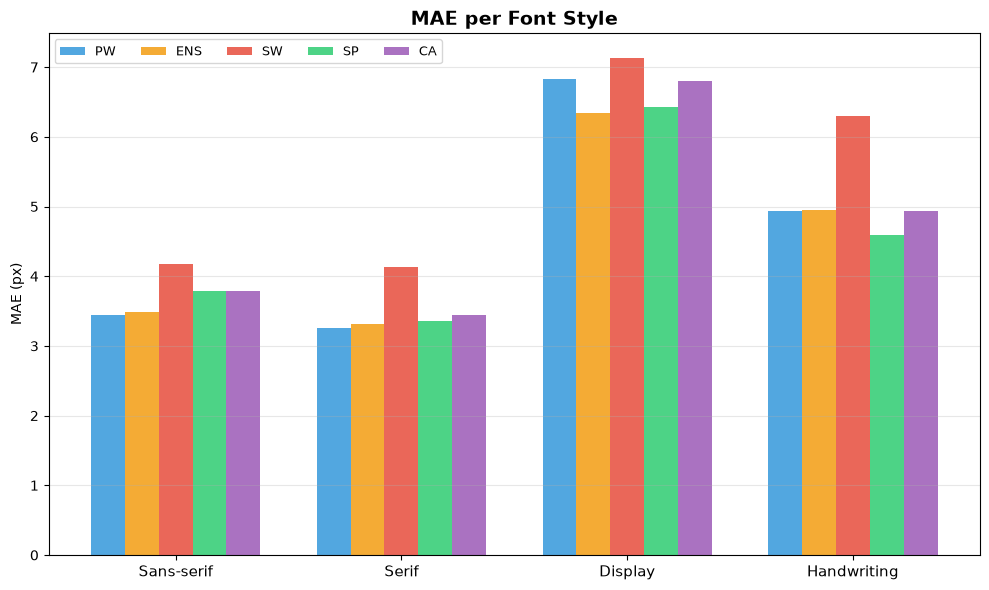

2026-08-13 00:41:15,294 | INFO | Sans-serif: PW=3.44 ENS=3.48 SW=4.17 SP=3.79 CA=3.78
2026-08-13 00:41:15,410 | INFO | Serif: PW=3.26 ENS=3.32 SW=4.13 SP=3.36 CA=3.45
2026-08-13 00:41:15,504 | INFO | Display: PW=6.83 ENS=6.35 SW=7.13 SP=6.43 CA=6.81
2026-08-13 00:41:15,591 | INFO | Handwriting: PW=4.93 ENS=4.95 SW=6.30 SP=4.60 CA=4.94


In [51]:
# Per-Style MAE Bar Chart
style_order = ["Sans-serif", "Serif", "Display", "Handwriting"]
model_cols = [
    ("PW", "ae_pw", "#3498db"), ("ENS", "ae_ens", "#f39c12"),
    ("SW", "ae_sw", "#e74c3c"), ("SP", "ae_sp", "#2ecc71"),
    ("CA", "ae_ca", "#9b59b6"),
]

x = np.arange(len(style_order))
w = 0.15
fig, ax = plt.subplots(figsize=(10, 6))
for offset, (name, col, color) in enumerate(model_cols):
    vals = [results_df[results_df["style"]==sty][col].mean() for sty in style_order]
    ax.bar(x + (offset - 2) * w, vals, w, label=name, color=color, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(style_order, fontsize=11)
ax.set_ylabel("MAE (px)")
ax.set_title("MAE per Font Style", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, ncol=5); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(XAI_DIR / "09_per_style_mae.png", dpi=150, bbox_inches="tight"); plt.show()

for sty in style_order:
    sub = results_df[results_df["style"] == sty]
    log.info("%s: PW=%.2f ENS=%.2f SW=%.2f SP=%.2f CA=%.2f",
             sty, sub["ae_pw"].mean(), sub["ae_ens"].mean(), sub["ae_sw"].mean(),
             sub["ae_sp"].mean(), sub["ae_ca"].mean())

## Section 10: Cumulative Error Distribution

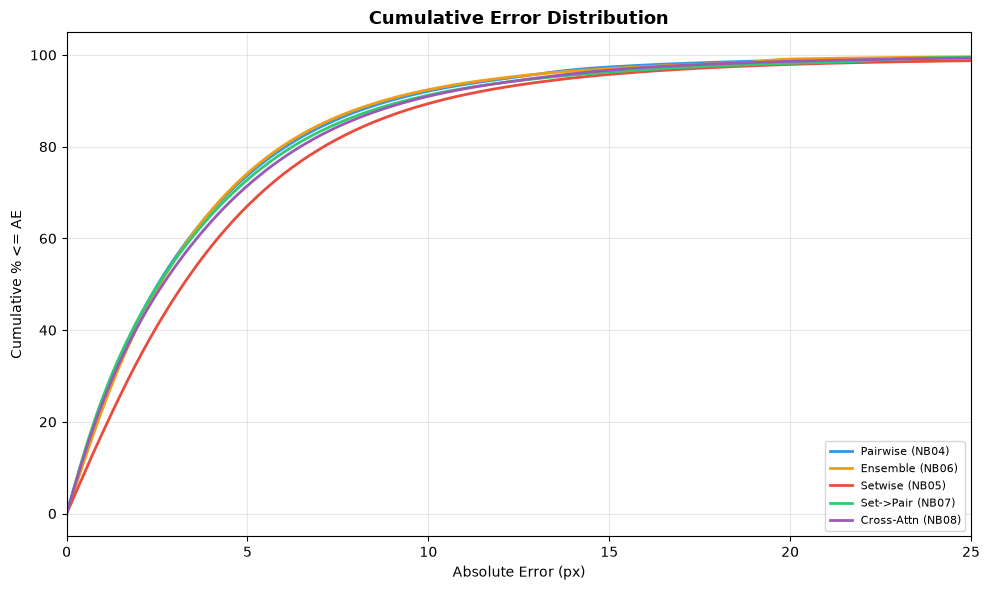

2026-08-13 00:41:21,717 | INFO | AE<=5: PW 73.8% ENS 74.2% SW 67.1% SP 72.8% CA 71.5%
2026-08-13 00:41:21,729 | INFO | AE<=10: PW 92.1% ENS 92.4% SW 89.4% SP 91.2% CA 91.0%
2026-08-13 00:41:21,741 | INFO | AE<=15: PW 97.4% ENS 97.0% SW 95.8% SP 96.3% CA 96.7%
2026-08-13 00:41:21,753 | INFO | AE<=20: PW 98.8% ENS 99.1% SW 97.9% SP 98.2% CA 98.6%


In [52]:
# Cumulative Error (5 models)
ae_pw = results_df["ae_pw"].values; ae_ens = results_df["ae_ens"].values; ae_sw = results_df["ae_sw"].values
ae_sp = results_df["ae_sp"].values; ae_ca = results_df["ae_ca"].values

fig, ax = plt.subplots(figsize=(10, 6))
ts = np.linspace(0, 40, 400)
all_curves = []
for ae, label, color in [
    (ae_pw, "Pairwise (NB04)", "#3498db"), (ae_ens, "Ensemble (NB06)", "#f39c12"),
    (ae_sw, "Setwise (NB05)", "#e74c3c"), (ae_sp, "Set->Pair (NB07)", "#2ecc71"),
    (ae_ca, "Cross-Attn (NB08)", "#9b59b6"),
]:
    pcts = [(ae <= t).mean() * 100 for t in ts]
    ax.plot(ts, pcts, linewidth=2, label=label, color=color)
    all_curves.append((label, color, pcts))
ax.set_xlabel("Absolute Error (px)"); ax.set_ylabel("Cumulative % <= AE")
ax.set_title("Cumulative Error Distribution", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(0, 25)
plt.tight_layout(); plt.savefig(XAI_DIR / "10_cumulative_error.png", dpi=150, bbox_inches="tight"); plt.show()
for t in [5, 10, 15, 20]:
    log.info("AE<=%d: PW %.1f%% ENS %.1f%% SW %.1f%% SP %.1f%% CA %.1f%%",
             t, (ae_pw<=t).mean()*100, (ae_ens<=t).mean()*100, (ae_sw<=t).mean()*100, (ae_sp<=t).mean()*100, (ae_ca<=t).mean()*100)

## Section 11: Error Distributions per Letter Pair

Histograms of absolute error for the best and worst letter pair of each model. Shows how error is distributed across fonts for specific pairs — tight distributions for easy pairs (e.g., round-round), wide right-skewed for hard pairs (e.g., W, V, T).

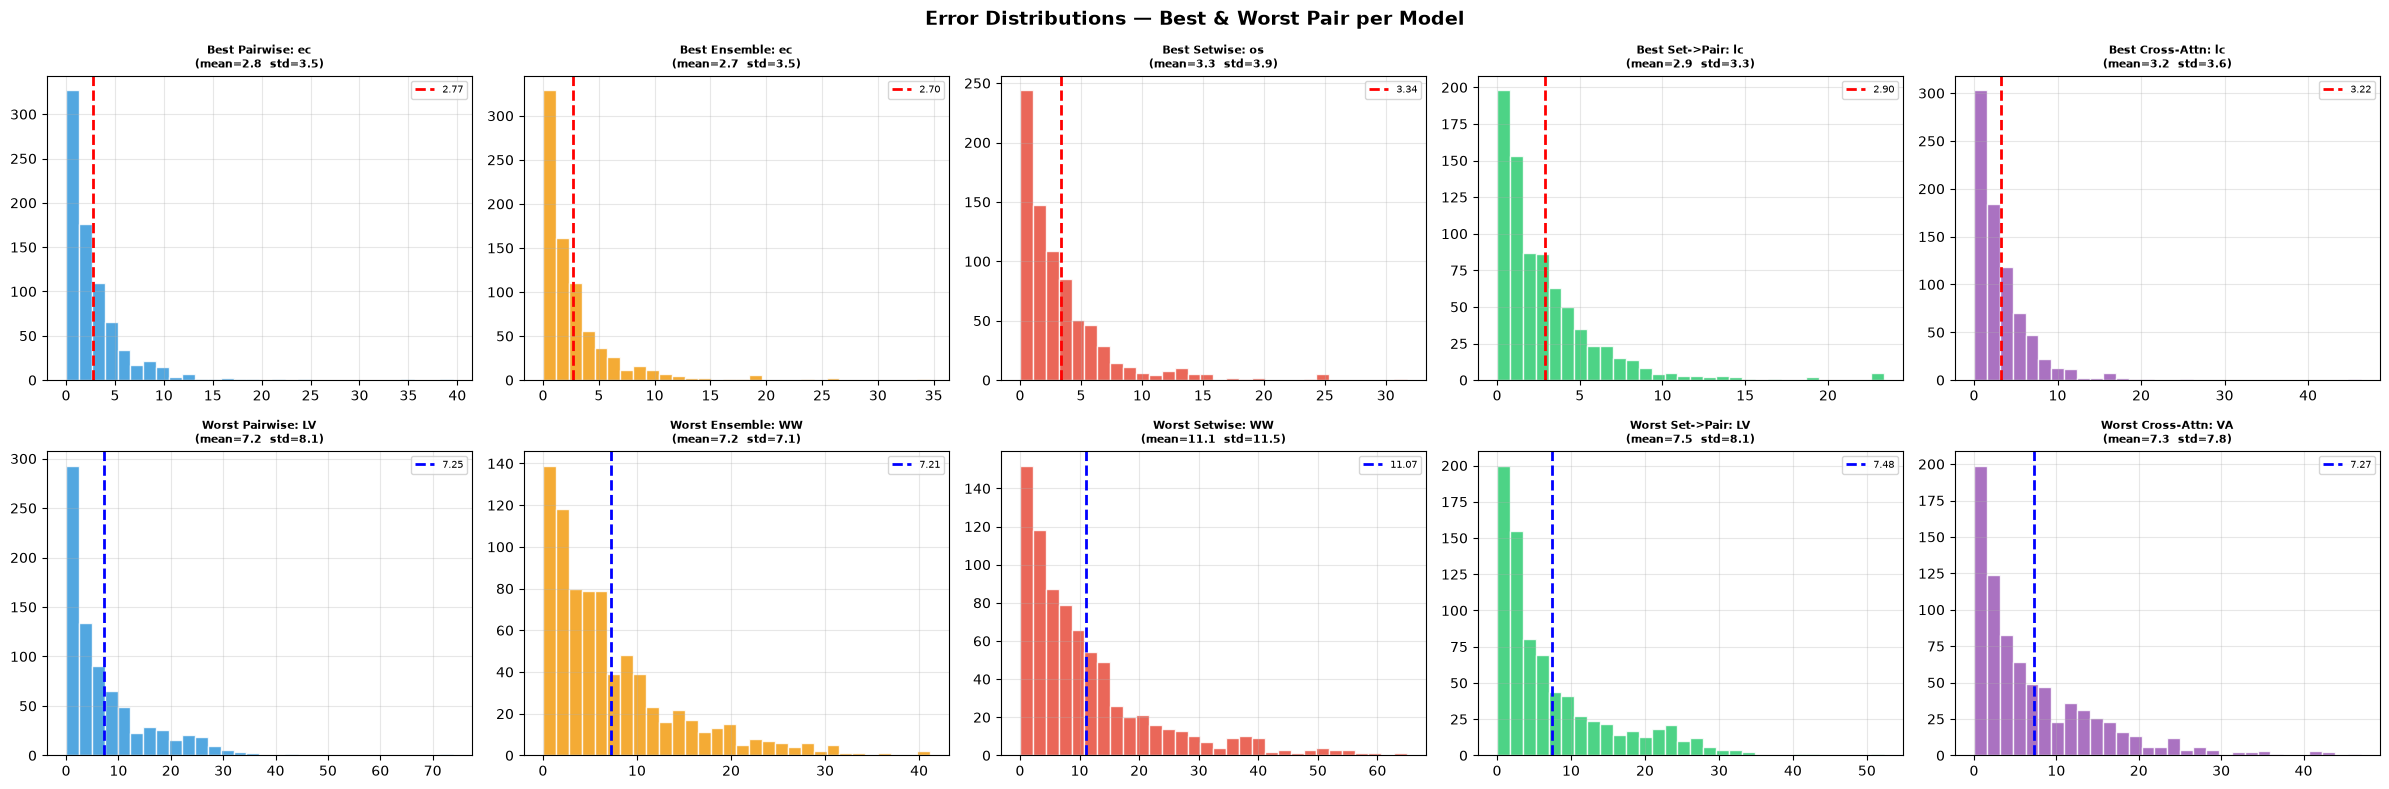

In [53]:
# Error Distributions per Pair — 5 models, best & worst pair each
models_m = [
    ("ae_pw", "Pairwise", "#3498db"), ("ae_ens", "Ensemble", "#f39c12"),
    ("ae_sw", "Setwise", "#e74c3c"), ("ae_sp", "Set->Pair", "#2ecc71"),
    ("ae_ca", "Cross-Attn", "#9b59b6"),
]
ps = results_df.groupby(["idx1", "idx2"]).agg(**{f"m_{col}": (col, "mean") for col, _, _ in models_m}).reset_index()

fig, axes = plt.subplots(2, len(models_m), figsize=(24, 8))
for ci, (col, label, color) in enumerate(models_m):
    m_col = f"m_{col}"
    best_idx = ps[m_col].idxmin()
    i1_b, i2_b = int(ps.loc[best_idx, "idx1"]), int(ps.loc[best_idx, "idx2"])
    g1b, g2b = LATIN_52[i1_b], LATIN_52[i2_b]
    eb = results_df[(results_df["idx1"]==i1_b) & (results_df["idx2"]==i2_b)][col]
    axes[0, ci].hist(eb, bins=30, color=color, edgecolor="white", alpha=0.85)
    axes[0, ci].axvline(eb.mean(), color="red", linestyle="--", linewidth=2, label=f"{eb.mean():.2f}")
    axes[0, ci].set_title(f"Best {label}: {g1b}{g2b}\n(mean={eb.mean():.1f}  std={eb.std():.1f})", fontsize=8, fontweight="bold")
    axes[0, ci].legend(fontsize=7); axes[0, ci].grid(True, alpha=0.3)

    worst_idx = ps[m_col].idxmax()
    i1_w, i2_w = int(ps.loc[worst_idx, "idx1"]), int(ps.loc[worst_idx, "idx2"])
    g1w, g2w = LATIN_52[i1_w], LATIN_52[i2_w]
    ew = results_df[(results_df["idx1"]==i1_w) & (results_df["idx2"]==i2_w)][col]
    axes[1, ci].hist(ew, bins=30, color=color, edgecolor="white", alpha=0.85)
    axes[1, ci].axvline(ew.mean(), color="blue", linestyle="--", linewidth=2, label=f"{ew.mean():.2f}")
    axes[1, ci].set_title(f"Worst {label}: {g1w}{g2w}\n(mean={ew.mean():.1f}  std={ew.std():.1f})", fontsize=8, fontweight="bold")
    axes[1, ci].legend(fontsize=7); axes[1, ci].grid(True, alpha=0.3)

fig.suptitle("Error Distributions — Best & Worst Pair per Model", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(XAI_DIR / "11_error_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 12: Best & Worst Cases per Style

For each font style and each model, the fonts with the lowest (Best) and highest (Worst) MAE. Each cell overlays the ground-truth (black) and the model's prediction (colored).


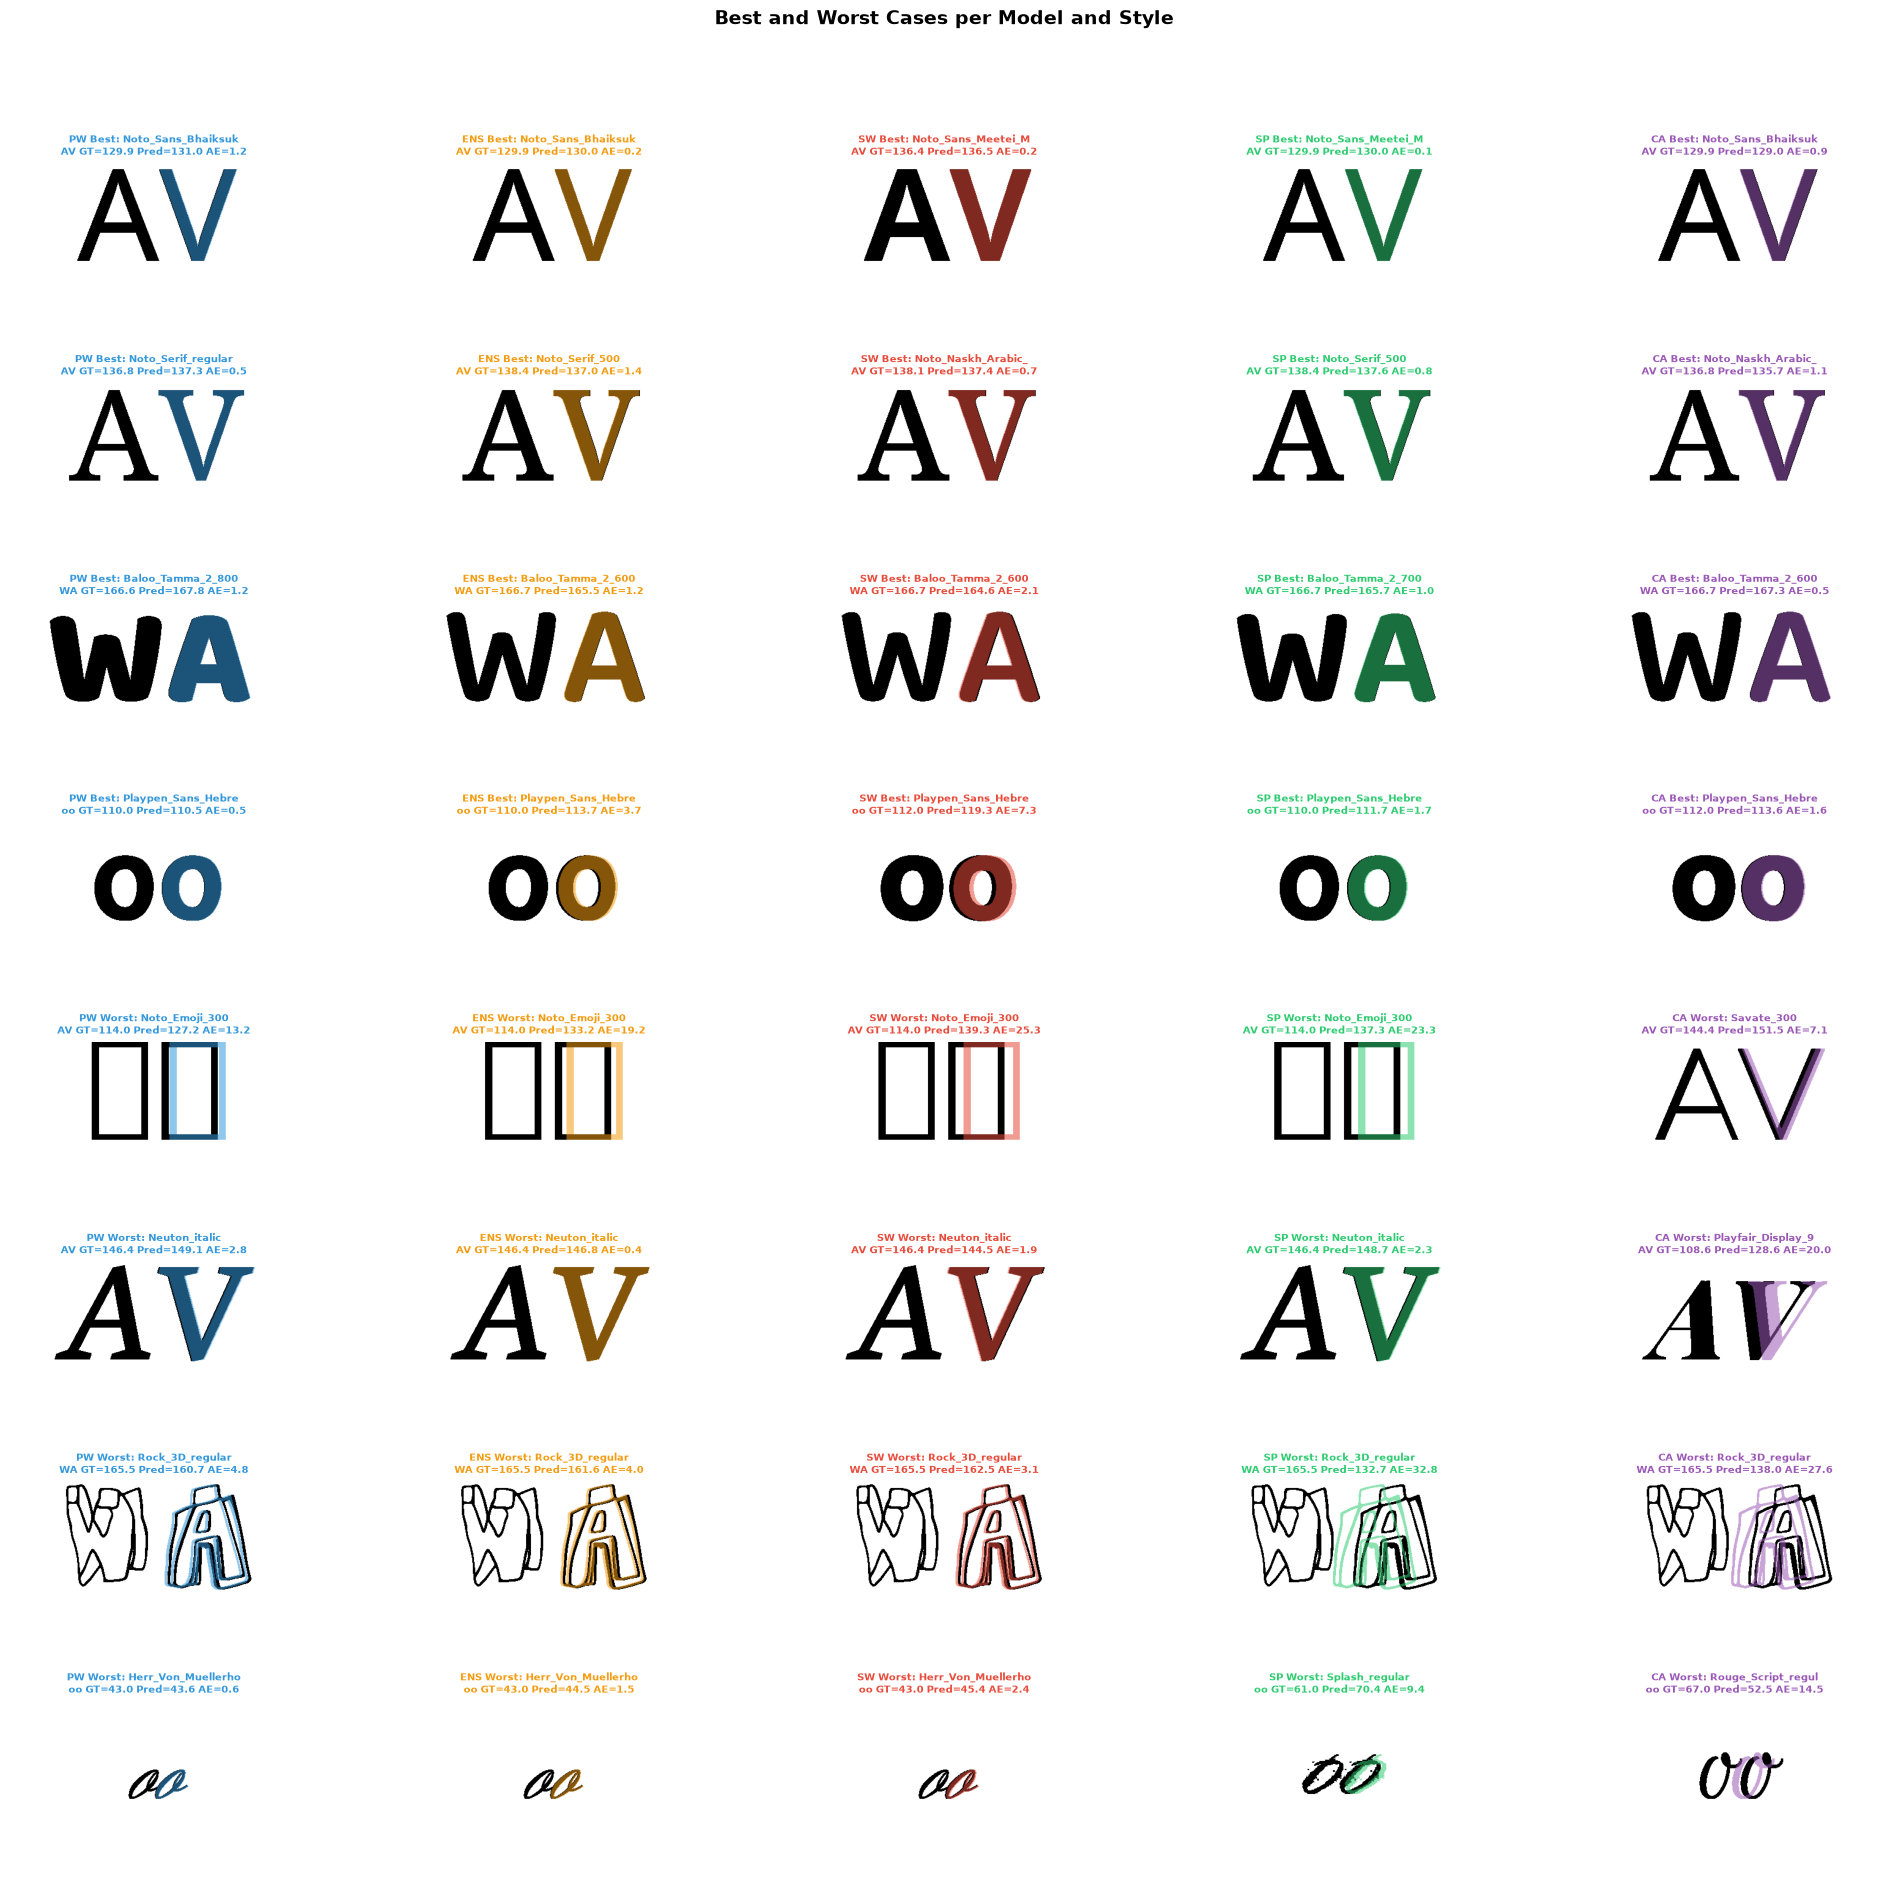

2026-08-13 00:41:42,793 | INFO | Best Sans-serif PW: Noto_Sans_Bhaiksuki_regul (MAE=0.56)
2026-08-13 00:41:42,794 | INFO | Worst Sans-serif PW: Noto_Emoji_300 (MAE=13.17)
2026-08-13 00:41:42,795 | INFO | Best Sans-serif ENS: Noto_Sans_Bhaiksuki_regul (MAE=0.72)
2026-08-13 00:41:42,796 | INFO | Worst Sans-serif ENS: Noto_Emoji_300 (MAE=19.21)
2026-08-13 00:41:42,798 | INFO | Best Sans-serif SW: Noto_Sans_Meetei_Mayek_60 (MAE=1.14)
2026-08-13 00:41:42,798 | INFO | Worst Sans-serif SW: Noto_Emoji_300 (MAE=25.25)
2026-08-13 00:41:42,800 | INFO | Best Sans-serif SP: Noto_Sans_Meetei_Mayek_re (MAE=0.42)
2026-08-13 00:41:42,800 | INFO | Worst Sans-serif SP: Noto_Emoji_300 (MAE=22.47)
2026-08-13 00:41:42,802 | INFO | Best Sans-serif CA: Noto_Sans_Bhaiksuki_regul (MAE=0.44)
2026-08-13 00:41:42,802 | INFO | Worst Sans-serif CA: Savate_300 (MAE=18.80)
2026-08-13 00:41:42,803 | INFO | Best Serif PW: Noto_Serif_regular (MAE=0.61)
2026-08-13 00:41:42,808 | INFO | Worst Serif PW: Neuton_italic (MAE=8

In [54]:
# Best & Worst Cases per Style
def render_best_overlay(imgs, cents, i_left, i_right, gt_dist, pred_dist, pred_rgb, glyph_h=256):
    cL, cR = cents[i_left], cents[i_right]
    pad = 15; H = glyph_h + 30
    left_cx = glyph_h // 2 + pad
    lx0 = int(left_cx - cL[0])
    gt_rx0 = int(left_cx + gt_dist - cR[0])
    pred_rx0 = int(left_cx + pred_dist - cR[0])
    mn = min(lx0, gt_rx0, pred_rx0, 0) - pad
    mx = max(lx0 + glyph_h, gt_rx0 + glyph_h, pred_rx0 + glyph_h) + pad
    sh = -mn; tw = mx + sh
    img = np.ones((H, tw, 3), dtype=np.float32)
    lc = lx0 + sh; w = min(glyph_h, tw - lc); h = min(glyph_h, H)
    if w > 0 and h > 0:
        m = imgs[i_left][:h, :w] > 0
        for ch in range(3): img[:h, lc:lc+w, ch][m] = 0
    rc = gt_rx0 + sh; w = min(glyph_h, tw - rc); h = min(glyph_h, H)
    if w > 0 and h > 0:
        m = imgs[i_right][:h, :w] > 0
        for ch in range(3): img[:h, rc:rc+w, ch][m] = 0
    rc = pred_rx0 + sh; w = min(glyph_h, tw - rc); h = min(glyph_h, H)
    if w > 0 and h > 0:
        m = imgs[i_right][:h, :w] > 0
        ex = img[:h, rc:rc+w, :].copy()
        ex[m] = ex[m] * 0.45 + np.array(pred_rgb) * 0.55
        img[:h, rc:rc+w, :] = ex
    return img

font_mae_all = {
    "PW": font_mae_pw_series, "ENS": font_mae_ens, "SW": font_mae_sw,
    "SP": font_mae_sp, "CA": font_mae_ca,
}

model_list = [
    ("PW", "#3498db"), ("ENS", "#f39c12"), ("SW", "#e74c3c"),
    ("SP", "#2ecc71"), ("CA", "#9b59b6"),
]

styles_list = ["Sans-serif", "Serif", "Display", "Handwriting"]
rep_pairs = {
    "Sans-serif": ("A", "V"), "Serif": ("A", "V"),
    "Display": ("W", "A"), "Handwriting": ("o", "o"),
}

pred_col = {"PW": "pred_pw", "ENS": "pred_ens", "SW": "pred_sw", "SP": "pred_sp", "CA": "pred_ca"}
ae_col = {"PW": "ae_pw", "ENS": "ae_ens", "SW": "ae_sw", "SP": "ae_sp", "CA": "ae_ca"}

case_types = [("Best", False), ("Worst", True)]
n_st = len(styles_list)
n_mod = len(model_list)
n_rows = n_st * len(case_types)
fig, axes = plt.subplots(n_rows, n_mod, figsize=(20, 2.4 * n_rows))
for ct_idx, (case_label, use_worst) in enumerate(case_types):
    for si, sty in enumerate(styles_list):
        sts = [s for s in test_stems if stem_style.get(s) == sty]
        if len(sts) == 0: continue
        g1, g2 = rep_pairs[sty]
        row_idx = ct_idx * n_st + si
        for mi, (model, color) in enumerate(model_list):
            ax = axes[row_idx, mi]
            if use_worst:
                stem = max(sts, key=lambda s: font_mae_all[model].get(s, -1))
            else:
                stem = min(sts, key=lambda s: font_mae_all[model].get(s, 999))
            gz = np.load(GLYPH_DIR / f"{stem}.npz")
            imgs = gz["glyph_images"]; cents = gz["centroids_canvas"]; nf = list(gz["glyph_names"])
            if g1 not in nf or g2 not in nf:
                ax.axis("off"); continue
            i1, i2 = nf.index(g1), nf.index(g2)
            sub = results_df[(results_df["stem"]==stem) & (results_df["glyph1"]==g1) & (results_df["glyph2"]==g2)]
            if len(sub) == 0: ax.axis("off"); continue
            row = sub.iloc[0]
            pred = row[pred_col[model]]; ae = row[ae_col[model]]; gt = row["target"]
            h = color.lstrip('#')
            model_rgb = tuple(int(h[i:i+2], 16)/255 for i in (0, 2, 4))
            canvas = render_best_overlay(imgs, cents, i1, i2, gt, pred, model_rgb)
            ax.imshow(canvas)
            ax.set_title(f"{model} {case_label}: {stem[:18]}\n{g1}{g2} GT={gt:.1f} Pred={pred:.1f} AE={ae:.1f}", fontsize=7, fontweight="bold", color=color)
            ax.axis("off")
        axes[row_idx, 0].set_ylabel(f"{sty}\n{case_label}", fontsize=8, fontweight="bold", rotation=0, labelpad=75, va="center")

fig.suptitle("Best and Worst Cases per Model and Style", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.subplots_adjust(top=0.90)
plt.savefig(XAI_DIR / "12_best_worst_cases_per_style.png", dpi=150, bbox_inches="tight"); plt.show()

for sty in styles_list:
    sts = [s for s in test_stems if stem_style.get(s) == sty]
    for model, _ in model_list:
        stem_best = min(sts, key=lambda s: font_mae_all[model].get(s, 999))
        stem_worst = max(sts, key=lambda s: font_mae_all[model].get(s, -1))
        log.info("Best %s %s: %s (MAE=%.2f)", sty, model, stem_best[:25], font_mae_all[model][stem_best])
        log.info("Worst %s %s: %s (MAE=%.2f)", sty, model, stem_worst[:25], font_mae_all[model][stem_worst])


## Section 13: t-SNE of ResNet18 Feature Space

2D projection of 512-d features for 52 letters from 20 fonts. Blue circles = uppercase, red squares = lowercase. Structurally similar letters (O/Q, I/l, P/R) cluster together regardless of font, confirming the feature space encodes morphological similarity.

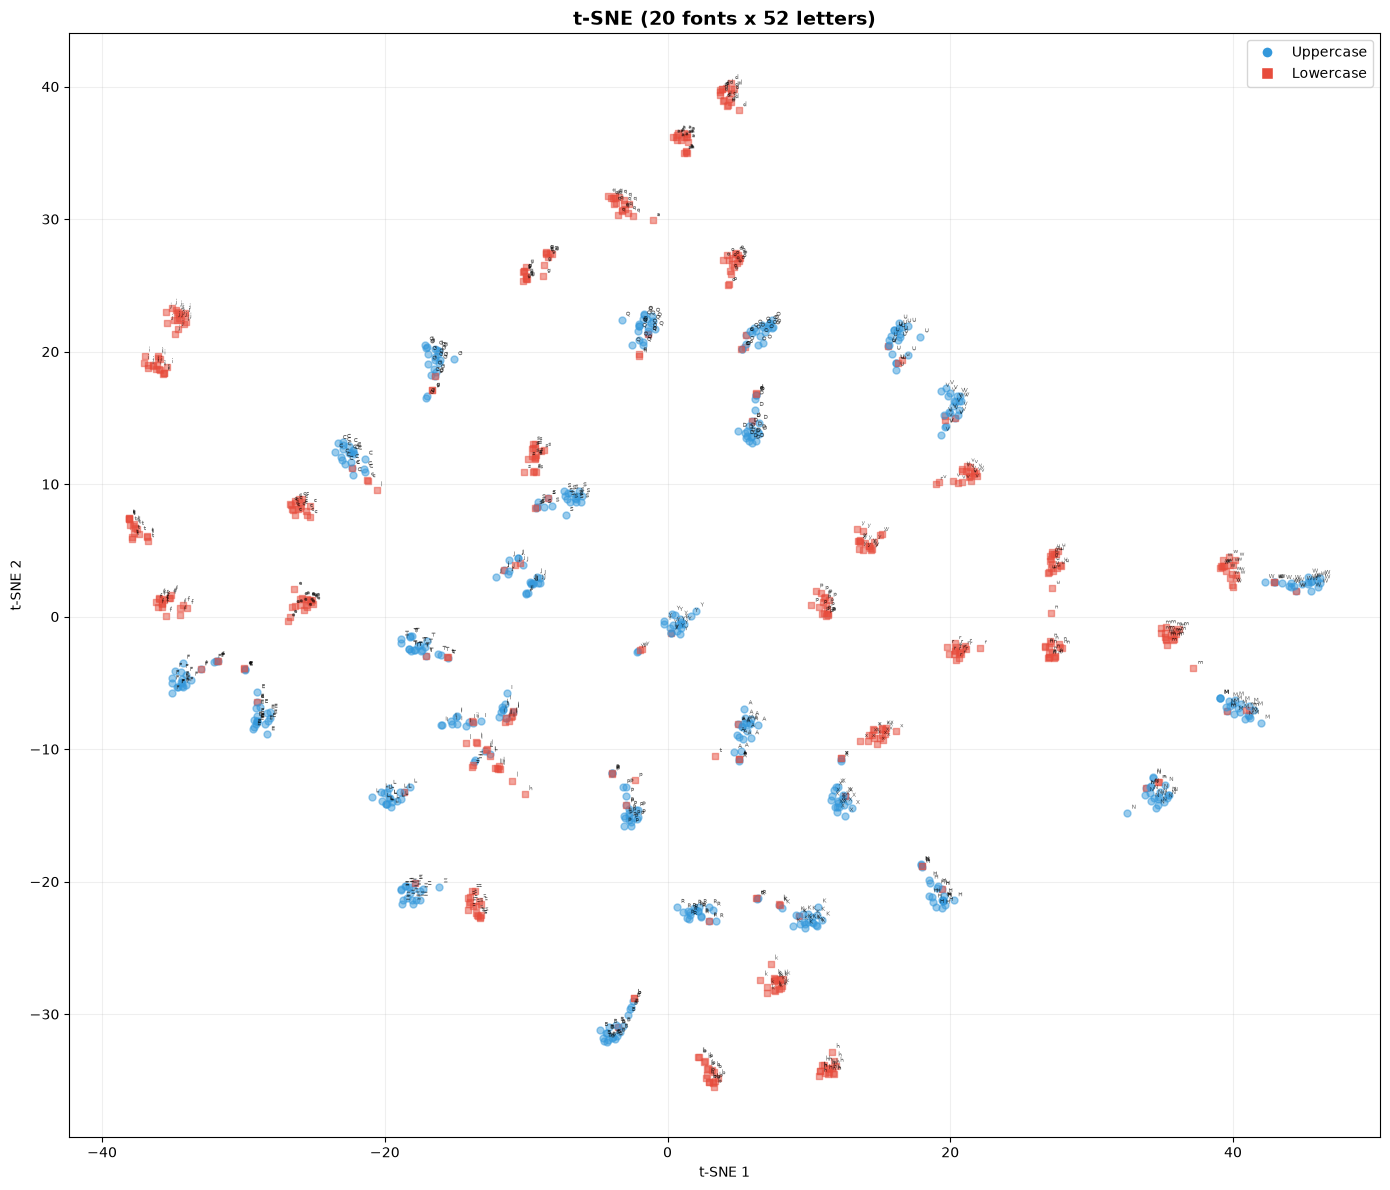

In [55]:
# t-SNE
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

viz_stems = rng.choice(test_stems, min(20, len(test_stems)), replace=False)
all_f = []; all_l = []
for s in viz_stems:
    feat = features_cache[s]; names = glyph_names_cache[s]
    for i, n in enumerate(names): all_f.append(feat[i]); all_l.append(n)
all_f = np.stack(all_f)
emb = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, max_iter=1000).fit_transform(all_f)
fig, ax = plt.subplots(figsize=(14, 12))
for i, l in enumerate(all_l):
    up = l.isupper(); c = "#3498db" if up else "#e74c3c"; m = "o" if up else "s"
    ax.scatter(emb[i, 0], emb[i, 1], c=c, marker=m, alpha=0.5, s=25)
    ax.annotate(l, (emb[i, 0], emb[i, 1]), fontsize=4, alpha=0.6, xytext=(3, 3), textcoords="offset points")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", label="Uppercase", markerfacecolor="#3498db", markersize=8),
    Line2D([0], [0], marker="s", color="w", label="Lowercase", markerfacecolor="#e74c3c", markersize=8),
], fontsize=10)
ax.set_title(f"t-SNE ({len(viz_stems)} fonts x 52 letters)", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.savefig(XAI_DIR / "13_tsne_features.png", dpi=150, bbox_inches="tight"); plt.show()

In [56]:
# Summary
print("=" * 65)
print("XAI ANALYSIS — COMPLETE SUMMARY")
print("=" * 65)
print(f"\nData: {len(test_stems)} test fonts, {len(results_df):,} pairs")
print(f"Styles: {dict(Counter(stem_style.values()))}")

maes = {c: results_df[c].mean() for c in ["ae_pw", "ae_ens", "ae_sw", "ae_sp", "ae_ca"]}
print(f"\nMAE: PW={maes['ae_pw']:.2f} ENS={maes['ae_ens']:.2f} SW={maes['ae_sw']:.2f} SP={maes['ae_sp']:.2f} CA={maes['ae_ca']:.2f}")

print("\nFigures:")
figures_list = [
    ("", "01_gt_heatmaps.png"),
    ("", "02_error_heatmaps.png"),
    ("", "03_letter_ranking.png"),
    ("", "04_shap_importance.png"),
    ("", "05_gradcam.png"),
    ("", "06_self_attention.png"),
    ("", "07_cross_attention.png"),
    ("", "08_per_font_scatter.png"),
    ("", "09_per_style_mae.png"),
    ("", "10_cumulative_error.png"),
    ("", "11_error_distributions.png"),
    ("", "12_best_worst_cases_per_style.png"),
    ("", "13_tsne_features.png"),
]
for i, (tag, f) in enumerate(figures_list, 1):
    p = XAI_DIR / f
    tag_str = f" {tag}" if tag else ""
    if p.exists():
        print(f"  {i:2d}. {p.name} ({p.stat().st_size/1024:.1f} KB){tag_str}")

print(f"\nSHAP: Visual={pct_featA+pct_featB:.1f}% | Identity={pct_ohA+pct_ohB:.1f}%")
n_total = len(font_df)
ens_better_val = (font_df["mae_ens"] < font_df["mae_pw"]).sum()
sw_better_val = (font_df["mae_sw"] < font_df["mae_pw"]).sum()
print(f"ENS > PW: {ens_better_val}/{n_total} ({100*ens_better_val/n_total:.1f}%) fonts")
print(f"SW > PW: {sw_better_val}/{n_total} ({100*sw_better_val/n_total:.1f}%) fonts")
print("=" * 65)

XAI ANALYSIS — COMPLETE SUMMARY

Data: 786 test fonts, 2,125,344 pairs
Styles: {'Display': 80, 'Sans-serif': 463, 'Serif': 167, 'Handwriting': 76}

MAE: PW=3.89 ENS=3.88 SW=4.67 SP=4.04 CA=4.13

Figures:
   1. 01_gt_heatmaps.png (97.3 KB)
   2. 02_error_heatmaps.png (181.0 KB)
   3. 03_letter_ranking.png (101.5 KB)
   4. 04_shap_importance.png (74.6 KB)
   5. 05_gradcam.png (400.1 KB)
   6. 06_self_attention.png (635.8 KB)
   7. 07_cross_attention.png (104.7 KB)
   8. 08_per_font_scatter.png (431.7 KB)
   9. 09_per_style_mae.png (28.1 KB)
  10. 10_cumulative_error.png (94.0 KB)
  11. 11_error_distributions.png (183.0 KB)
  12. 12_best_worst_cases_per_style.png (645.6 KB)
  13. 13_tsne_features.png (269.5 KB)

SHAP: Visual=96.0% | Identity=4.0%
ENS > PW: 406/786 (51.7%) fonts
SW > PW: 340/786 (43.3%) fonts
